Testing KL divergence functions...
KL divergence: 0.026984
Symmetric KL divergence: 0.028182


Processing datasets: 100%|████████████████████| 100/100 [00:01<00:00, 62.46it/s]
/var/folders/2x/1nbr4z456238x43xpmlql0nm0000gn/T/ipykernel_53473/280162244.py:389: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)



Valid computations: 100/100

KL DIVERGENCE STATISTICS (q_perturb||q_final)
KL(q_W_final||q_W_perturb):
  Mean: 2.987208402860e-10
  Std:  3.577193469586e-10
  Min:  6.506661875960e-11
  Max:  3.137582638146e-09
  Median: 2.190179149153e-10

KL(q_z_final||q_z_perturb):
  Mean: 3.125237402202e-11
  Std:  5.609630185923e-11
  Min:  1.552202810728e-12
  Max:  5.436027183947e-10
  Median: 2.010352995185e-11

Threshold used in GCorr computation: 1e-300 = 1.00e-300
Smallest non-zero KL_W: 6.506661875960e-11
Smallest non-zero KL_z: 1.552202810728e-12

GCORR STATISTICS
Initial GCorr: Mean=0.0495, Std=0.0422, Min=0.0002, Max=0.1721
Max GCorr: Mean=0.8466, Std=1.6003, Min=0.0002, Max=10.2138
Ratio (Max/Init): Mean=89.9615, Std=455.2651


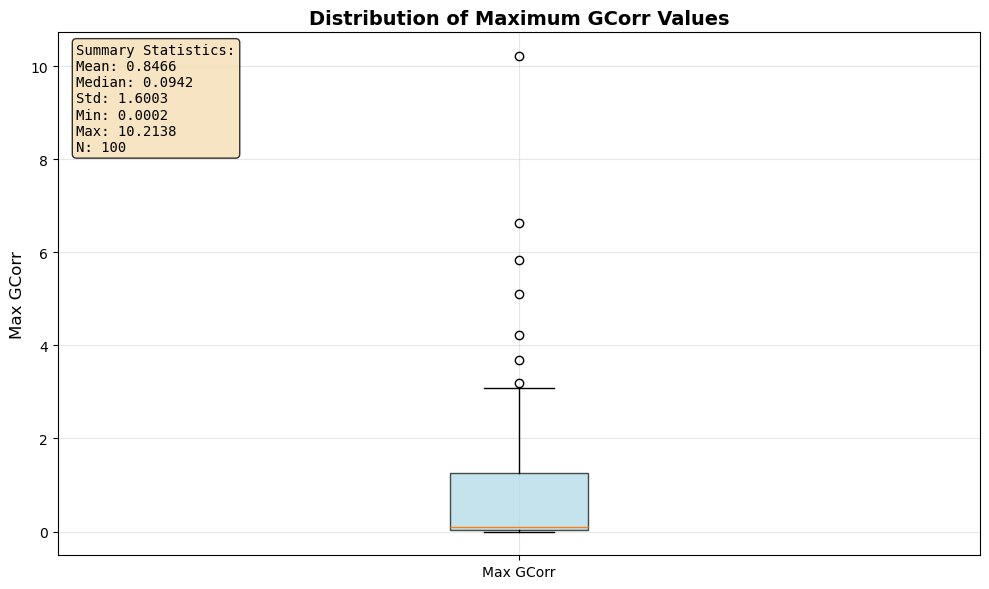

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import multivariate_normal
import scipy.linalg
from tqdm import tqdm

# random seed for reproducibility
np.random.seed(42)

def create_diagonal_matrix(n, a):
    """Create an n*n matrix filled with zeros with diagonal elements set to value 'a'"""
    matrix = np.zeros((n, n))
    np.fill_diagonal(matrix, a)
    return matrix

def kl_mvn(to, fr):
    """Calculate KL(to||fr), where to and fr are pairs of means and covariance matrices"""
    m_to, S_to = to
    m_fr, S_fr = fr
    
    d = m_fr - m_to
    c, lower = scipy.linalg.cho_factor(S_fr)
    
    def solve(B):
        return scipy.linalg.cho_solve((c, lower), B)
    
    def logdet(S):
        return np.linalg.slogdet(S)[1]
    
    term1 = np.trace(solve(S_to))
    term2 = logdet(S_fr) - logdet(S_to)
    term3 = d.T @ solve(d)
    
    return (term1 + term2 + term3 - len(d))/2

def kl_mvn_stable(to, fr):
    """Calculate KL(to||fr) using numerically stable log-space computation"""
    m_to, S_to = to
    m_fr, S_fr = fr
    
    d = m_fr - m_to
    
    # Use Cholesky decomposition for numerical stability
    try:
        c, lower = scipy.linalg.cho_factor(S_fr)
        
        def solve(B):
            return scipy.linalg.cho_solve((c, lower), B)
        
        # Compute log determinants using slogdet for stability
        sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
        sign_to, logdet_to = np.linalg.slogdet(S_to)
        
        if sign_fr <= 0 or sign_to <= 0:
            # Fall back to regular computation if determinants are non-positive
            return kl_mvn(to, fr)
        
        term1 = np.trace(solve(S_to))
        term2 = logdet_fr - logdet_to
        term3 = d.T @ solve(d)
        
        return (term1 + term2 + term3 - len(d))/2
    
    except np.linalg.LinAlgError:
        # Fall back to regular computation if Cholesky fails
        return kl_mvn(to, fr)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    Calculate KL divergence between two matrix normal distributions:
    N(mu_1, I_m ⊗ Sigma_1) and N(mu_2, I_m ⊗ Sigma_2)
    
    For matrix normal N(M, U, V), the distribution is over M with:
    - Mean: M
    - Covariance: U ⊗ V (Kronecker product)
    
    Here we assume U = I_m (identity matrix of size m×m where m is number of rows of mu)
    """
    # Get dimensions
    m, n = mu1.shape  # m rows, n columns
    
    # For matrix normal with U = I_m, we can compute KL as sum over rows
    # Each row follows N(mu_i, Sigma) where mu_i is the i-th row
    
    total_kl = 0.0
    
    for i in range(m):
        # Extract i-th row from each mean matrix
        row_mu1 = mu1[i, :]  # Shape: (n,)
        row_mu2 = mu2[i, :]  # Shape: (n,)
        
        # Compute KL divergence for this row using stable version
        to = (row_mu1, Sigma1)
        fr = (row_mu2, Sigma2)
        
        kl_row = kl_mvn_stable(to, fr)
        total_kl += kl_row
    
    return total_kl

def symmetric_matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """Compute symmetric KL divergence: 0.5 * (KL(P1||P2) + KL(P2||P1))"""
    kl1 = matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2)
    kl2 = matrix_kl_divergence(mu2, Sigma2, mu1, Sigma1)
    return 0.5 * (kl1 + kl2)

def generate_data_matrix(n, d, rho):
    cov_matrix = np.full((d, d), rho)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = np.random.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T

def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1/n) * np.dot(x, x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    tau = 1 / sigma_squared
    return tau

def make_psd(matrix, min_eigenvalue=1e-10):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(eigenvalues, min_eigenvalue)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k, verbose=False):
    increment = 50
    max_iterations = 100000
    iteration = 0
    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1
        sigma_W_inv = tau * np.dot(mu_z.T, mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * np.dot(np.dot(x, mu_z), sigma_W)
        sigma_z_inv = tau * (d * sigma_W + np.dot(mu_W.T, mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * np.dot(np.dot(x.T, mu_W), sigma_z)
        if iteration % 100 == 0:
            term1 = d * sigma_W + np.dot(mu_W.T, mu_W)
            term2 = n * sigma_z + np.dot(mu_z.T, mu_z)
            B = np.trace(np.dot(term1, term2))
            C = d * np.trace(np.dot(Lambda, sigma_W)) + np.trace(np.dot(np.dot(mu_W, Lambda), mu_W.T))
            D = np.trace(n * sigma_z + np.dot(mu_z.T, mu_z))
            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)
            ELBO = (tau * np.trace(np.dot(np.dot(mu_W, mu_z.T), x.T)) 
                    - (tau / 2) * B - 0.5 * C - 0.5 * D 
                    + 0.5 * k * logdet_W + 0.5 * k * logdet_z)
            ELBOS.append(ELBO)
        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])
    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def generate_psd_perturbation(original_matrix, epsilon):
    eigenvalues, eigenvectors = np.linalg.eigh(original_matrix)
    perturbed_eigenvalues = np.maximum(eigenvalues + epsilon, 1e-10)
    perturbed_matrix = eigenvectors @ np.diag(perturbed_eigenvalues) @ eigenvectors.T
    return perturbed_matrix

def compute_delta(mu_W, sigma_W, mu_z, sigma_z, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, x, tau, d, n):
    Gamma_W = d * sigma_W + np.dot(mu_W.T, mu_W)
    Gamma_z = n * sigma_z + np.dot(mu_z.T, mu_z)
    Gamma_W_star = d * sigma_W_star + np.dot(mu_W_star.T, mu_W_star)
    Gamma_z_star = n * sigma_z_star + np.dot(mu_z_star.T, mu_z_star)
    mu_W_diff = mu_W - mu_W_star
    mu_z_diff = mu_z - mu_z_star
    term1 = tau * np.trace(np.dot(np.dot(mu_z_diff.T, x.T), mu_W_diff))
    term2 = 0.5 * tau * np.trace(np.dot((Gamma_W - Gamma_W_star), (Gamma_z - Gamma_z_star).T))
    delta = term1 - term2
    return delta

def compute_gcorr(mu_W, sigma_W, mu_z, sigma_z, mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref, x, tau, d, n):
    sym_kl_W = symmetric_matrix_kl_divergence(mu_W, sigma_W, mu_W_ref, sigma_W_ref)
    sym_kl_z = symmetric_matrix_kl_divergence(mu_z, sigma_z, mu_z_ref, sigma_z_ref)
    
    threshold = 1e-300  
    
    if sym_kl_W > threshold and sym_kl_z > threshold:
        delta = compute_delta(mu_W, sigma_W, mu_z, sigma_z, mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref, x, tau, d, n)
        log_delta = np.log(max(abs(delta), threshold))
        log_kl_W = np.log(sym_kl_W)
        log_kl_z = np.log(sym_kl_z)
        log_gcorr = log_delta - 0.5 * (log_kl_W + log_kl_z)
        gcorr = np.exp(log_gcorr)
        return gcorr, delta, sym_kl_W, sym_kl_z
    else:
        return None, None, sym_kl_W, sym_kl_z

def recurrence_iteration_with_tracking(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k, 
                                      mu_W_star, sigma_W_star, mu_z_star, sigma_z_star):
    increment = 50
    max_iterations = 100000
    iteration = 0
    max_gcorr = 0
    initial_gcorr, _, _, _ = compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                                           mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                                           x, tau, d, n)
    max_gcorr = initial_gcorr if initial_gcorr is not None else 0
    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1
        if iteration % 50 == 0:
            gcorr, _, _, _ = compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                                           mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                                           x, tau, d, n)
            if gcorr is not None and gcorr > max_gcorr:
                max_gcorr = gcorr
        sigma_W_inv = tau * np.dot(mu_z.T, mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * np.dot(np.dot(x, mu_z), sigma_W)
        sigma_z_inv = tau * (d * sigma_W + np.dot(mu_W.T, mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * np.dot(np.dot(x.T, mu_W), sigma_z)
        if iteration % 100 == 0:
            term1 = d * sigma_W + np.dot(mu_W.T, mu_W)
            term2 = n * sigma_z + np.dot(mu_z.T, mu_z)
            B = np.trace(np.dot(term1, term2))
            C = d * np.trace(np.dot(Lambda, sigma_W)) + np.trace(np.dot(np.dot(mu_W, Lambda), mu_W.T))
            D = np.trace(n * sigma_z + np.dot(mu_z.T, mu_z))
            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)
            ELBO = (tau * np.trace(np.dot(np.dot(mu_W, mu_z.T), x.T)) 
                    - (tau / 2) * B - 0.5 * C - 0.5 * D 
                    + 0.5 * k * logdet_W + 0.5 * k * logdet_z)
            ELBOS.append(ELBO)
        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])
    return mu_W, sigma_W, mu_z, sigma_z, ELBOS, max_gcorr, initial_gcorr

def run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale=1e-15):
    x = generate_data_matrix(n, d, rho)
    tau = estimate_tau_ppca(x, k)
    Lambda = alpha * np.eye(k)
    mu_W = np.random.randn(d, k)
    sigma_W = np.eye(k)
    mu_z = np.random.randn(n, k)
    sigma_z = np.eye(k)
    ELBOS = []
    mu_W_final, sigma_W_final, mu_z_final, sigma_z_final, ELBOS = recurrence_iteration(
        mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k)
    
    # Create perturbations
    mu_W_pert = mu_W_final + perturbation_scale * np.random.randn(*mu_W_final.shape)
    mu_z_pert = mu_z_final + perturbation_scale * np.random.randn(*mu_z_final.shape)
    sigma_W_pert = generate_psd_perturbation(sigma_W_final, perturbation_scale)
    sigma_z_pert = generate_psd_perturbation(sigma_z_final, perturbation_scale)
    
    # Compute KL divergences from perturbed to final (q_perturb||q_final)
    kl_W_pert_to_final = matrix_kl_divergence(mu_W_final, sigma_W_final,mu_W_pert, sigma_W_pert)
    kl_z_pert_to_final = matrix_kl_divergence(mu_z_final, sigma_z_final,mu_z_pert, sigma_z_pert,)
    
    ELBOS_new = []
    _, _, _, _, _, max_gcorr, init_gcorr = recurrence_iteration_with_tracking(
        mu_W_pert, sigma_W_pert, mu_z_pert, sigma_z_pert, Lambda, ELBOS_new, x, tau, d, n, k,
        mu_W_final, sigma_W_final, mu_z_final, sigma_z_final)
    
    return {
        'tau': tau,
        'initial_gcorr': init_gcorr,
        'max_gcorr': max_gcorr,
        'kl_W_pert_to_final': kl_W_pert_to_final,
        'kl_z_pert_to_final': kl_z_pert_to_final,
        'n_iterations_first': len(ELBOS),
        'n_iterations_second': len(ELBOS_new)
    }

# Example usage and testing
if __name__ == "__main__":
    # Test the KL divergence functions
    print("Testing KL divergence functions...")
    
    # Test case 1: Simple 2x2 matrices
    mu1 = np.array([[1, 2], [3, 4]])
    mu2 = np.array([[1.1, 2.1], [3.1, 4.1]])
    sigma1 = np.eye(2)
    sigma2 = 1.1 * np.eye(2)
    
    kl_div = matrix_kl_divergence(mu1, sigma1, mu2, sigma2)
    sym_kl_div = symmetric_matrix_kl_divergence(mu1, sigma1, mu2, sigma2)
    
    print(f"KL divergence: {kl_div:.6f}")
    print(f"Symmetric KL divergence: {sym_kl_div:.6f}")
    
    # Main execution
    d, n, k = 2, 20, 1
    rho, alpha, N = 0.9, 1.0, 100  # Reduced N for testing
    perturbation_scale = 1e-7

    results = []
    initial_gcorrs = []
    max_gcorrs = []
    kl_W_values = []
    kl_z_values = []

    for i in tqdm(range(N), desc="Processing datasets"):
        result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale)
        results.append(result)
        
        # Debug: Check for None values
        if result['initial_gcorr'] is None:
            print(f"Dataset {i}: initial_gcorr is None")
        if result['max_gcorr'] is None:
            print(f"Dataset {i}: max_gcorr is None")
            
        initial_gcorrs.append(result['initial_gcorr'])
        max_gcorrs.append(result['max_gcorr'])
        kl_W_values.append(result['kl_W_pert_to_final'])
        kl_z_values.append(result['kl_z_pert_to_final'])

    # Filter out None values before computing statistics
    initial_gcorrs_clean = [x for x in initial_gcorrs if x is not None]
    max_gcorrs_clean = [x for x in max_gcorrs if x is not None]
    
    print(f"\nValid computations: {len(initial_gcorrs_clean)}/{len(initial_gcorrs)}")
    
    # Print KL divergence statistics with high precision
    print("\n" + "="*60)
    print("KL DIVERGENCE STATISTICS (q_perturb||q_final)")
    print("="*60)
    
    # Determine appropriate precision based on the minimum non-zero value
    min_nonzero_W = min([x for x in kl_W_values if x > 0]) if any(x > 0 for x in kl_W_values) else 1e-16
    min_nonzero_z = min([x for x in kl_z_values if x > 0]) if any(x > 0 for x in kl_z_values) else 1e-16
    
    # Use scientific notation for very small values
    def format_small_number(x):
        if x == 0:
            return "0.0"
        elif x < 1e-6:
            return f"{x:.12e}"
        else:
            return f"{x:.12f}"
    
    # KL(q_W_perturb||q_W_final) statistics
    print(f"KL(q_W_final||q_W_perturb):")
    print(f"  Mean: {format_small_number(np.mean(kl_W_values))}")
    print(f"  Std:  {format_small_number(np.std(kl_W_values))}")
    print(f"  Min:  {format_small_number(np.min(kl_W_values))}")
    print(f"  Max:  {format_small_number(np.max(kl_W_values))}")
    print(f"  Median: {format_small_number(np.median(kl_W_values))}")
    
    # KL(q_z_perturb||q_z_final) statistics
    print(f"\nKL(q_z_final||q_z_perturb):")
    print(f"  Mean: {format_small_number(np.mean(kl_z_values))}")
    print(f"  Std:  {format_small_number(np.std(kl_z_values))}")
    print(f"  Min:  {format_small_number(np.min(kl_z_values))}")
    print(f"  Max:  {format_small_number(np.max(kl_z_values))}")
    print(f"  Median: {format_small_number(np.median(kl_z_values))}")
    
    # Print threshold information for context
    print(f"\nThreshold used in GCorr computation: 1e-300 = {1e-300:.2e}")
    print(f"Smallest non-zero KL_W: {format_small_number(min_nonzero_W)}")
    print(f"Smallest non-zero KL_z: {format_small_number(min_nonzero_z)}")
    
    print("\n" + "="*60)
    print("GCORR STATISTICS")
    print("="*60)
    
    # Print stats for initial GCorr
    if initial_gcorrs_clean:
        print(f"Initial GCorr: Mean={np.mean(initial_gcorrs_clean):.4f}, Std={np.std(initial_gcorrs_clean):.4f}, "
              f"Min={np.min(initial_gcorrs_clean):.4f}, Max={np.max(initial_gcorrs_clean):.4f}")
    else:
        print("Initial GCorr: No valid values")
    
    # Print stats for max GCorr
    if max_gcorrs_clean:
        print(f"Max GCorr: Mean={np.mean(max_gcorrs_clean):.4f}, Std={np.std(max_gcorrs_clean):.4f}, "
              f"Min={np.min(max_gcorrs_clean):.4f}, Max={np.max(max_gcorrs_clean):.4f}")
    else:
        print("Max GCorr: No valid values")
    
    # Compute ratios only for valid pairs
    ratios = [m/i for m, i in zip(max_gcorrs_clean, initial_gcorrs_clean) if i > 0]
    if ratios:
        print(f"Ratio (Max/Init): Mean={np.mean(ratios):.4f}, Std={np.std(ratios):.4f}")
    else:
        print("Ratio (Max/Init): No valid ratios")
    
    # Create box plot for max GCorr values
    if max_gcorrs_clean:
        plt.figure(figsize=(10, 6))
        
        # Create box plot
        box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][0].set_alpha(0.7)
        
        # Add title and labels
        plt.title('Distribution of Maximum GCorr Values', fontsize=14, fontweight='bold')
        plt.ylabel('Max GCorr', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Add summary statistics as text
        stats_text = f"""Summary Statistics:
Mean: {np.mean(max_gcorrs_clean):.4f}
Median: {np.median(max_gcorrs_clean):.4f}
Std: {np.std(max_gcorrs_clean):.4f}
Min: {np.min(max_gcorrs_clean):.4f}
Max: {np.max(max_gcorrs_clean):.4f}
N: {len(max_gcorrs_clean)}"""
        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=10, fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid max GCorr values to plot")

Running experiments across multiple rho values...


Varying rho: 100%|██████████████████████████████| 10/10 [00:27<00:00,  2.70s/it]


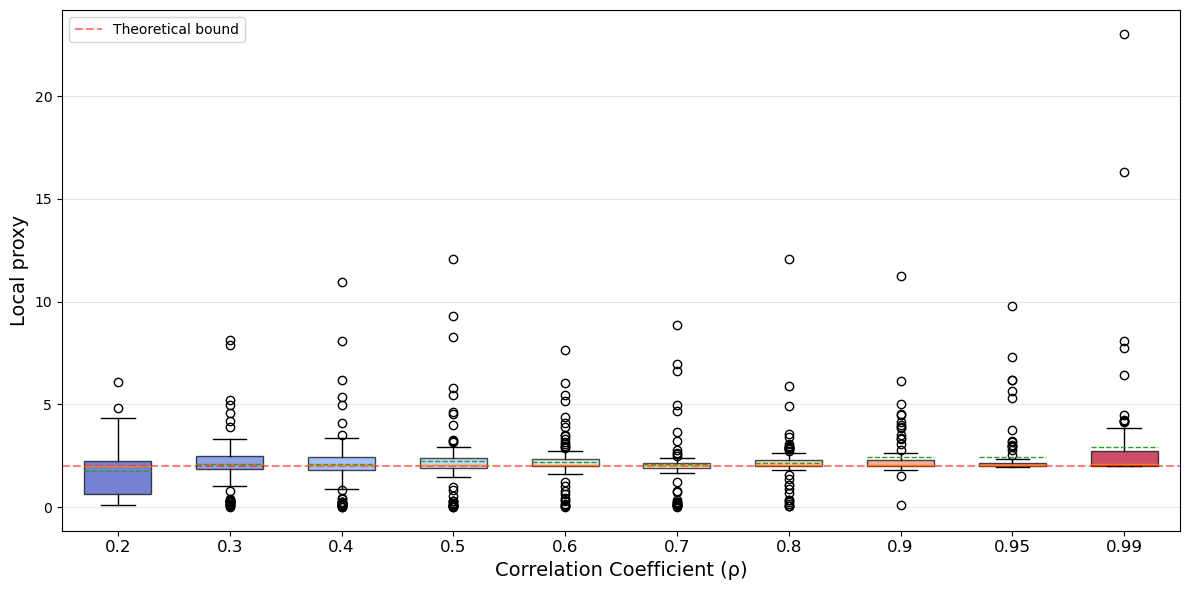

In [53]:
# =============================================================================
# ANALYSIS ACROSS MULTIPLE RHO VALUES
# =============================================================================
rho_values = [0.2,0.3,0.4,0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
all_max_gcorrs_by_rho = []

# Parameters
d = 3
n = 20
k = 2
alpha = 1.0
N_per_rho = 100
perturbation_scale = 1e-7

print("Running experiments across multiple rho values...")

for rho in tqdm(rho_values, desc="Varying rho"):
    max_gcorrs_rho = []
    for _ in range(N_per_rho):
        result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale)
        max_gcorrs_rho.append(result['max_gcorr'])
    all_max_gcorrs_by_rho.append(max_gcorrs_rho)

# Plot box plot
plt.figure(figsize=(12, 6))

box = plt.boxplot(all_max_gcorrs_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

# Set colors for each box
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# X-axis setup
plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=12)
plt.xlabel('Correlation Coefficient (ρ)', fontsize=14)

# Y-axis
plt.ylabel('Local proxy', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Reference line at y=2
plt.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Theoretical bound')
plt.legend()

plt.tight_layout()
#plt.savefig("maxGCorrboxplot_30_3.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [55]:
import pandas as pd

summary_stats = []

for rho, max_gcorrs_rho in zip(rho_values, all_max_gcorrs_by_rho):
    mean_val = np.mean(max_gcorrs_rho)
    std_val = np.std(max_gcorrs_rho)
    min_val = np.min(max_gcorrs_rho)
    max_val = np.max(max_gcorrs_rho)
    summary_stats.append({
        'rho': rho,
        'mean_max_gcorr': mean_val,
        'std_max_gcorr': std_val,
        'min_max_gcorr': min_val,
        'max_max_gcorr': max_val
    })

df_summary = pd.DataFrame(summary_stats)
print("\nSummary statistics for max GCorr by rho:\n")
print(df_summary.to_string(index=False))



Summary statistics for max GCorr by rho:

 rho  mean_max_gcorr  std_max_gcorr  min_max_gcorr  max_max_gcorr
0.20        1.743297       1.079291       0.096943       6.077805
0.30        2.100621       1.326313       0.008158       8.140739
0.40        2.113142       1.556653       0.002695      10.962382
0.50        2.259802       1.700347       0.024003      12.081177
0.60        2.209222       1.121413       0.001436       7.633594
0.70        2.078734       1.254350       0.023680       8.853917
0.80        2.168817       1.284623       0.034657      12.084238
0.90        2.414975       1.171296       0.087635      11.244061
0.95        2.429190       1.188692       1.934355       9.787913
0.99        2.909358       2.664745       1.985661      23.041507


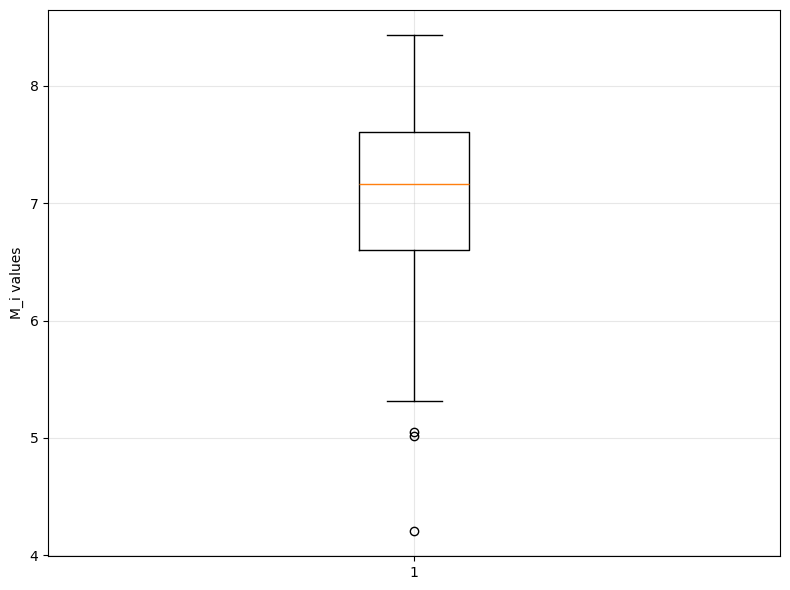


Summary Statistics for M_i values:
Mean: 7.0304
Median: 7.1607
Std: 0.8093
Min: 4.2036
Max: 8.4328
Number of successful computations: 100/100


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import eigh

def generate_data_matrix(n, d, rho):
    """Generate a single data matrix from multivariate Gaussian with correlation rho"""
    # Create covariance matrix with 1s on diagonal and rho elsewhere
    cov_matrix = np.full((d, d), rho)
    np.fill_diagonal(cov_matrix, 1.0)
    
    # Generate n data points from multivariate Gaussian
    data_points = np.random.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    
    # Return as (d, n) matrix where each column is a data point
    return data_points.T

def estimate_tau_ppca(x, k):
    """Estimate tau using PPCA MLE approach"""
    d, n = x.shape
    
    # sample covariance matrix S = (1/n) * X * X^T
    S = (1/n) * np.dot(x, x.T)
    
    # Get eigenvalues in descending order
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort in descending order
    
    # Estimate sigma^2 using PPCA formula
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])  # Average of smallest (d-k) eigenvalues
    else:
        sigma_squared = 1e-8  # Small value to avoid division by zero
    
    tau = 1 / sigma_squared
    return tau

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    """CAVI recurrence iteration"""
    increment = 50
    max_iterations = 100000  # Add safety limit
    iteration = 0
    
    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1
        
        # Update sigma_W
        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z)) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        
        # Update mu_W
        mu_W = tau * np.dot(np.dot(x, mu_z), sigma_W)
        
        # Update sigma_z
        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        
        # Update mu_z
        mu_z = tau * np.dot(np.dot(x.T, mu_W), sigma_z)
        
        # Compute ELBO
        B = np.dot(mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W), 
                   mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z))
        C = d * np.trace(np.dot(Lambda, sigma_W)) + np.trace(np.dot(np.dot(mu_W, Lambda), mu_W.T))
        D = np.trace(mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z))
        
        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)
        
        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")
        
        ELBO = (tau * np.trace(np.dot(np.dot(mu_W, mu_z.T), x.T)) 
                - (tau / 2) * np.trace(B) 
                - 0.5 * C 
                - 0.5 * D 
                + 0.5 * d * logdet_W 
                + 0.5 * n * logdet_z)
        
        ELBOS.append(ELBO)
        
        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])
    
    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def compute_M_i(x, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau, n, d):
    """Compute the M_i quantity for a given dataset"""
    gamma0 = (1/4) * (1 + math.e**(-1))
    
    # Compute Frobenius norms
    norm_sigma_W = np.linalg.norm(sigma_W_star, ord='fro')
    norm_sigma_z = np.linalg.norm(sigma_z_star, ord='fro')
    norm_mu_W = np.linalg.norm(mu_W_star, ord='fro')
    norm_mu_z = np.linalg.norm(mu_z_star, ord='fro')
    norm_x = np.linalg.norm(x, ord='fro')
    
    # Key terms
    key_term = (np.linalg.norm(x - np.dot(mu_W_star, mu_z_star.T), 'fro') + 
                np.linalg.norm(np.dot(mu_W_star, mu_z_star.T), 'fro'))
    key_term_star = norm_x + 2 * norm_mu_W * norm_mu_z
    
    # Four terms
    term1 = ((norm_sigma_W * norm_sigma_z)**0.5 * key_term_star) / gamma0
    term2 = 2 * math.e * (norm_sigma_W * norm_sigma_z) * math.sqrt(n * d)
    term3 = (norm_sigma_W * (norm_sigma_z**0.5) * math.sqrt(2 * d * math.e) * norm_mu_z) / (gamma0**0.5)
    term4 = ((norm_sigma_W**0.5) * norm_sigma_z * math.sqrt(2 * n * math.e) * norm_mu_W) / (gamma0**0.5)
    
    # M_i is tau times the maximum of the four terms
    M_i = tau * max(term1, term2, term3, term4)
    
    return M_i

def get_box(n, d, k, rho):
    """
    Main function to generate boxplot data for Bayesian CAVI experiment
    
    Parameters:
    n: number of data points
    d: data dimension
    k: rank
    rho: correlation parameter between -1 and 1
    
    Returns:
    M: list of M_i values for boxplot
    """
    # Set random seed
    np.random.seed(42)
    
    # Initialize parameters
    mu_W = np.full((d, k), 0.1)
    sigma_W = np.eye(k)
    mu_z = np.full((n, k), 0.1)
    sigma_z = np.eye(k)
    
    # Lambda matrix
    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))  # Extend if k > 2
    Lambda = np.diag(diagonal_elements[:k])
    
    # Store M_i values
    M = []
    
    # Generate 100 matrices and process each
    for i in range(100):
        # Generate data matrix x_i
        x_i = generate_data_matrix(n, d, rho)
        
        # Estimate tau using PPCA
        tau_i = estimate_tau_ppca(x_i, k)
        
        # Run CAVI
        ELBOS_initial = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS_initial = recurrence_iteration(
                mu_W.copy(), sigma_W.copy(), mu_z.copy(), sigma_z.copy(), 
                Lambda, ELBOS_initial, x_i, tau_i, d, n, k
            )
            
            # Compute M_i
            M_i = compute_M_i(x_i, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_i, n, d)
            M.append(M_i)
            
        except Exception as e:
            continue
    
    # Create boxplot
    plt.figure(figsize=(8, 6))
    plt.boxplot(M)
    plt.ylabel('M_i values')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics for M_i values:")
    print(f"Mean: {np.mean(M):.4f}")
    print(f"Median: {np.median(M):.4f}")
    print(f"Std: {np.std(M):.4f}")
    print(f"Min: {np.min(M):.4f}")
    print(f"Max: {np.max(M):.4f}")
    print(f"Number of successful computations: {len(M)}/100")
    
    return M

# Example usage:
if __name__ == "__main__":
    # Test with sample parameters
    n, d, k, rho = 20, 2, 1, 0.5
    M_values = get_box(n, d, k, rho)

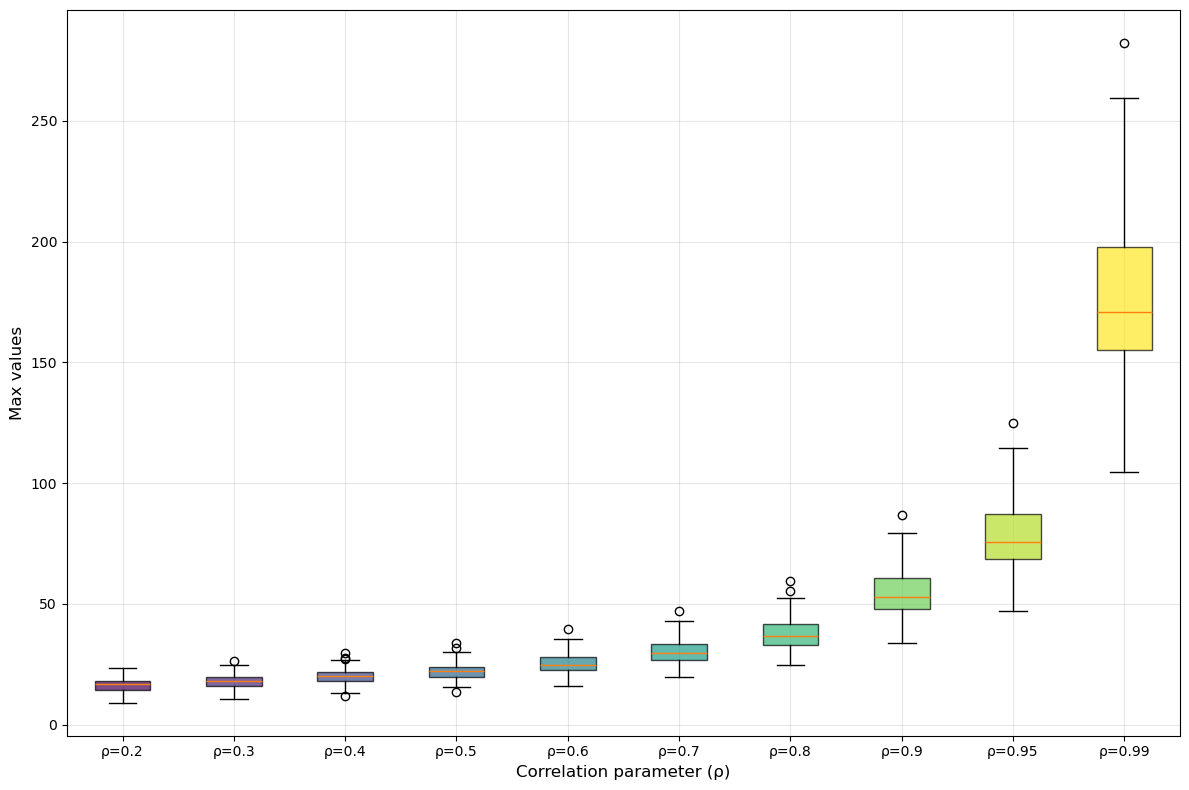


Summary Statistics by ρ value:
------------------------------------------------------------
ρ      Mean       Median     Std        Min        Max       
------------------------------------------------------------
0.2    16.5074    16.6947    2.8510     9.1085     23.4632   
0.3    17.9926    18.1957    2.9570     10.8555    26.3462   
0.4    19.9537    20.0331    3.2733     11.7725    29.7645   
0.5    22.3229    22.0468    3.6010     13.3674    33.9758   
0.6    25.4877    24.7367    4.1992     15.9032    39.4527   
0.7    30.1606    29.6029    5.2117     19.5987    47.1786   
0.8    37.6480    36.7102    6.7820     24.5972    59.6888   
0.9    54.4823    52.8660    10.0304    33.7347    87.0047   
0.95   78.0279    75.5002    14.4876    47.1924    124.8237  
0.99   176.1691   170.7998   33.0278    104.8161   282.2327  


In [59]:
# Cell for comparing M_i values across different rho values
import numpy as np
import matplotlib.pyplot as plt

def compare_rho_values():
    """
    Compare M_i distributions across different rho values
    Fixed parameters: n=20, d=2, k=1
    """
    # Fixed parameters
    n, d, k = 20, 3, 2
    
    # Sequence of rho values
    rho_values = [0.2,0.3,0.4,0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    
    # Store M_i values for each rho
    all_M_values = []
    rho_labels = []
    
    for rho in rho_values:
        # Get M_i values for this rho (without showing individual plots)
        # We'll modify get_box to return values without plotting
        M_values = get_box_silent(n, d, k, rho)
        all_M_values.append(M_values)
        rho_labels.append(f'ρ={rho}')
    
    # Create the comparison boxplot
    plt.figure(figsize=(12, 8))
    
    # Create boxplot with all rho values
    box_plot = plt.boxplot(all_M_values, tick_labels=rho_labels, patch_artist=True)
    
    # Customize the plot
    plt.xlabel('Correlation parameter (ρ)', fontsize=12)
    plt.ylabel('Max values', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Color the boxes with a gradient
    colors = plt.cm.viridis(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    plt.tight_layout()
    #plt.savefig("Upperboundplot30_3.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by ρ value:")
    print("-" * 60)
    print(f"{'ρ':<6} {'Mean':<10} {'Median':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
    print("-" * 60)
    
    for i, rho in enumerate(rho_values):
        M_vals = all_M_values[i]
        print(f"{rho:<6} {np.mean(M_vals):<10.4f} {np.median(M_vals):<10.4f} "
              f"{np.std(M_vals):<10.4f} {np.min(M_vals):<10.4f} {np.max(M_vals):<10.4f}")
    
    return all_M_values, rho_values

def get_box_silent(n, d, k, rho):
    """
    Modified version of get_box that returns M values without plotting
    """
    # Set random seed
    np.random.seed(412)
    
    # Initialize parameters
    mu_W = np.full((d, k), 0.1)
    sigma_W = np.eye(k)
    mu_z = np.full((n, k), 0.1)
    sigma_z = np.eye(k)
    
    # Lambda matrix
    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))
    Lambda = np.diag(diagonal_elements[:k])
    
    # Store M_i values
    M = []
    
    # Generate 100 matrices and process each
    for i in range(100):
        # Generate data matrix x_i
        x_i = generate_data_matrix(n, d, rho)
        
        # Estimate tau using PPCA
        tau_i = estimate_tau_ppca(x_i, k)
        
        # Run CAVI
        ELBOS_initial = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS_initial = recurrence_iteration(
                mu_W.copy(), sigma_W.copy(), mu_z.copy(), sigma_z.copy(), 
                Lambda, ELBOS_initial, x_i, tau_i, d, n, k
            )
            
            # Compute M_i
            M_i = compute_M_i(x_i, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_i, n, d)
            M.append(M_i)
            
        except Exception as e:
            continue
    
    return M

# Run the comparison
if __name__ == "__main__":
    all_M_values, rho_values = compare_rho_values()

Running experiments across multiple rho values...


Varying rho: 100%|██████████████████████████████| 12/12 [00:30<00:00,  2.55s/it]


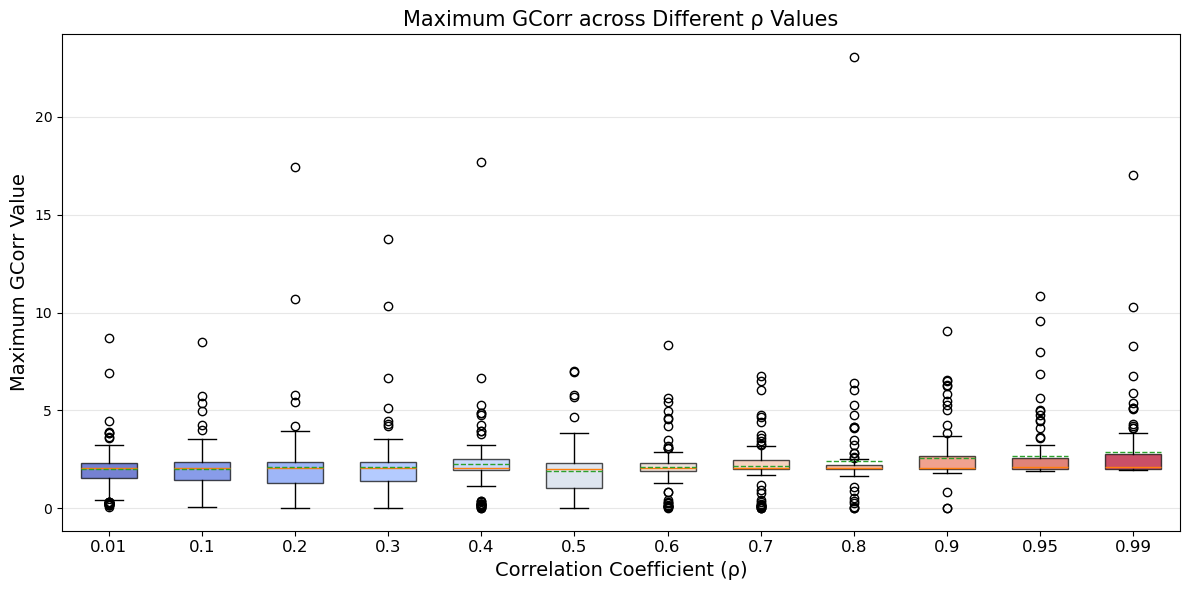

In [67]:
# =============================================================================
# ANALYSIS ACROSS MULTIPLE RHO VALUES
# =============================================================================
rho_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
all_max_gcorrs_by_rho = []

# Parameters
d = 3
n = 20
k = 2
alpha = 1.0
N_per_rho = 100
perturbation_scale = 1e-7

print("Running experiments across multiple rho values...")
for rho in tqdm(rho_values, desc="Varying rho"):
    max_gcorrs_rho = []
    for _ in range(N_per_rho):
        result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale)
        max_gcorrs_rho.append(result['max_gcorr'])
    all_max_gcorrs_by_rho.append(max_gcorrs_rho)

# Plot box plot
plt.figure(figsize=(12, 6))
box = plt.boxplot(all_max_gcorrs_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

# Set colors for each box
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# X-axis setup
plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=12)
plt.xlabel('Correlation Coefficient (ρ)', fontsize=14)

# Y-axis
plt.ylabel('Maximum GCorr Value', fontsize=14)
plt.title(f'Maximum GCorr across Different ρ Values', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig("maxGCorrboxplot_20_3_new.pdf", format="pdf", bbox_inches="tight")
plt.show()

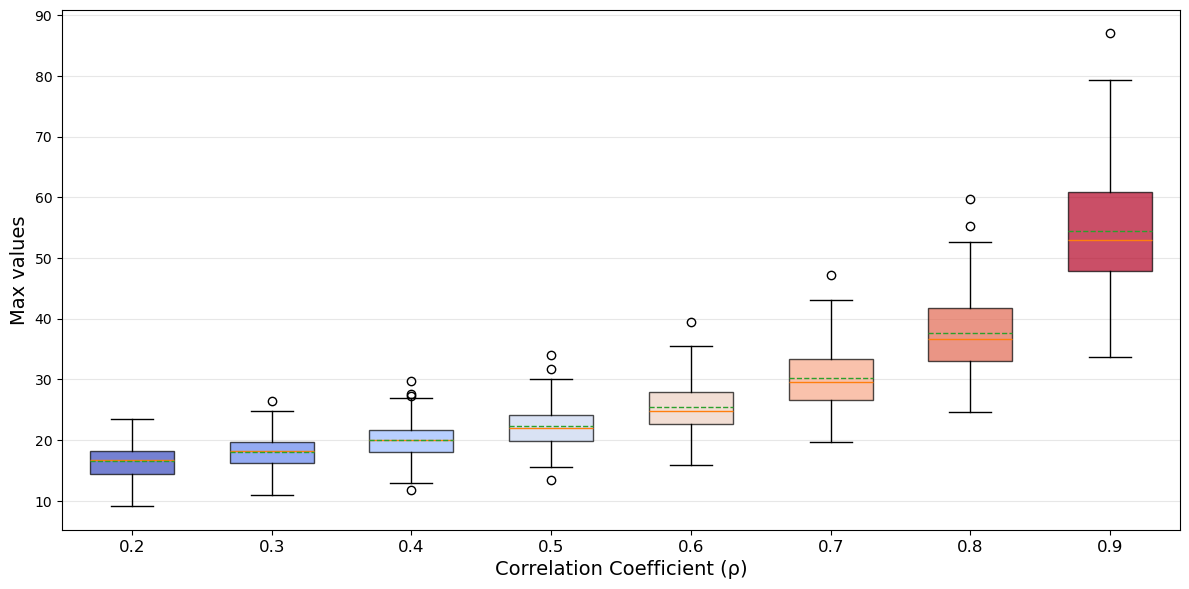


Summary Statistics by ρ value:
------------------------------------------------------------
ρ      Mean       Median     Std        Min        Max       
------------------------------------------------------------
0.2    16.5074    16.6947    2.8510     9.1085     23.4632   
0.3    17.9926    18.1957    2.9570     10.8555    26.3462   
0.4    19.9537    20.0331    3.2733     11.7725    29.7645   
0.5    22.3229    22.0468    3.6010     13.3674    33.9758   
0.6    25.4877    24.7367    4.1992     15.9032    39.4527   
0.7    30.1606    29.6029    5.2117     19.5987    47.1786   
0.8    37.6480    36.7102    6.7820     24.5972    59.6888   
0.9    54.4823    52.8660    10.0304    33.7347    87.0047   


In [63]:
# Cell for comparing M_i values across different rho values
import numpy as np
import matplotlib.pyplot as plt

def compare_rho_values():
    """
    Compare M_i distributions across different rho values
    Fixed parameters: n=20, d=3, k=2
    """
    # Fixed parameters
    n, d, k = 20, 3, 2
    
    # Sequence of rho values
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    
    # Store M_i values for each rho
    all_M_values = []
    
    for rho in rho_values:
        # Get M_i values for this rho (without showing individual plots)
        M_values = get_box_silent(n, d, k, rho)
        all_M_values.append(M_values)
    
    # Create the comparison boxplot (MATCH style/layout of reference code)
    plt.figure(figsize=(12, 6))
    box_plot = plt.boxplot(
        all_M_values,
        patch_artist=True,
        widths=0.6,
        showmeans=True,
        meanline=True
    )
    
    # Color the boxes (same scheme as reference)
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # X-axis setup: remove "ρ=..." labels, use raw rho values
    plt.xticks(
        ticks=range(1, len(rho_values) + 1),
        labels=rho_values,
        fontsize=12
    )
    plt.xlabel('Correlation Coefficient (ρ)', fontsize=14)
    
    # Y-axis label unchanged in meaning 
    plt.ylabel('Max values', fontsize=14)
    
    # Background/grid: ONLY horizontal grey lines
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    #plt.savefig("Upperboundplot30_3_need.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by ρ value:")
    print("-" * 60)
    print(f"{'ρ':<6} {'Mean':<10} {'Median':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
    print("-" * 60)
    
    for i, rho in enumerate(rho_values):
        M_vals = all_M_values[i]
        print(
            f"{rho:<6} {np.mean(M_vals):<10.4f} {np.median(M_vals):<10.4f} "
            f"{np.std(M_vals):<10.4f} {np.min(M_vals):<10.4f} {np.max(M_vals):<10.4f}"
        )
    
    return all_M_values, rho_values


def get_box_silent(n, d, k, rho):
    """
    Modified version of get_box that returns M values without plotting
    """
    # Set random seed
    np.random.seed(412)
    
    # Initialize parameters
    mu_W = np.full((d, k), 0.1)
    sigma_W = np.eye(k)
    mu_z = np.full((n, k), 0.1)
    sigma_z = np.eye(k)
    
    # Lambda matrix
    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))
    Lambda = np.diag(diagonal_elements[:k])
    
    # Store M_i values
    M = []
    
    # Generate 100 matrices and process each
    for i in range(100):
        # Generate data matrix x_i
        x_i = generate_data_matrix(n, d, rho)
        
        # Estimate tau using PPCA
        tau_i = estimate_tau_ppca(x_i, k)
        
        # Run CAVI
        ELBOS_initial = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS_initial = recurrence_iteration(
                mu_W.copy(),
                sigma_W.copy(),
                mu_z.copy(),
                sigma_z.copy(),
                Lambda,
                ELBOS_initial,
                x_i,
                tau_i,
                d,
                n,
                k
            )
            
            # Compute M_i
            M_i = compute_M_i(x_i, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_i, n, d)
            M.append(M_i)
            
        except Exception:
            continue
    
    return M


# Run the comparison
if __name__ == "__main__":
    all_M_values, rho_values = compare_rho_values()

Testing KL divergence functions...
KL divergence: 0.026984
Symmetric KL divergence: 0.028182


Processing datasets: 100%|████████████████████| 100/100 [00:52<00:00,  1.91it/s]


Valid computations: 100/100

KL DIVERGENCE STATISTICS (best perturbation per dataset)
KL(q_W_final||q_W_perturb):
  Mean:   3.252604408033e-10
  Std:    2.765943769060e-10
  Min:    7.867373419401e-11
  Max:    1.678783556613e-09
  Median: 2.491552519857e-10

KL(q_z_final||q_z_perturb):
  Mean:   3.534935011373e-11
  Std:    4.346816670414e-11
  Min:    2.995048653531e-12
  Max:    3.338730403257e-10
  Median: 2.538858012713e-11

GCORR STATISTICS (best perturbation per dataset)
Initial GCorr: Mean=0.1013, Std=0.0848, Min=0.0001, Max=0.3124
Max GCorr:     Mean=2.6873, Std=3.1666, Min=0.1194, Max=13.9898
Ratio (Max/Init): Mean=875.1360, Std=6567.8982



/var/folders/2x/1nbr4z456238x43xpmlql0nm0000gn/T/ipykernel_53473/2985271650.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)


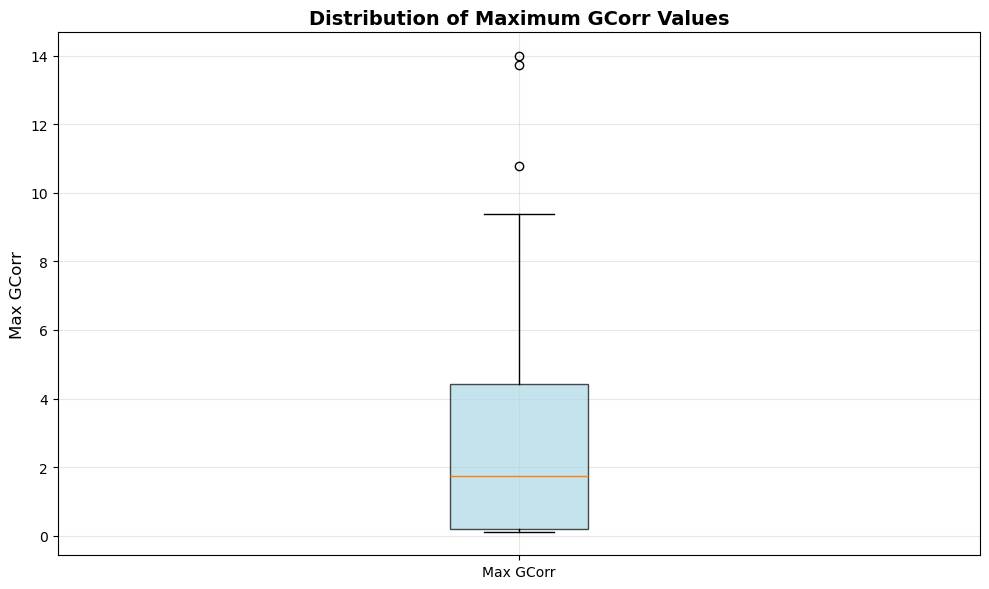

Running experiments across multiple rho values...


Varying rho: 100%|██████████████████████████████| 10/10 [14:13<00:00, 85.31s/it]


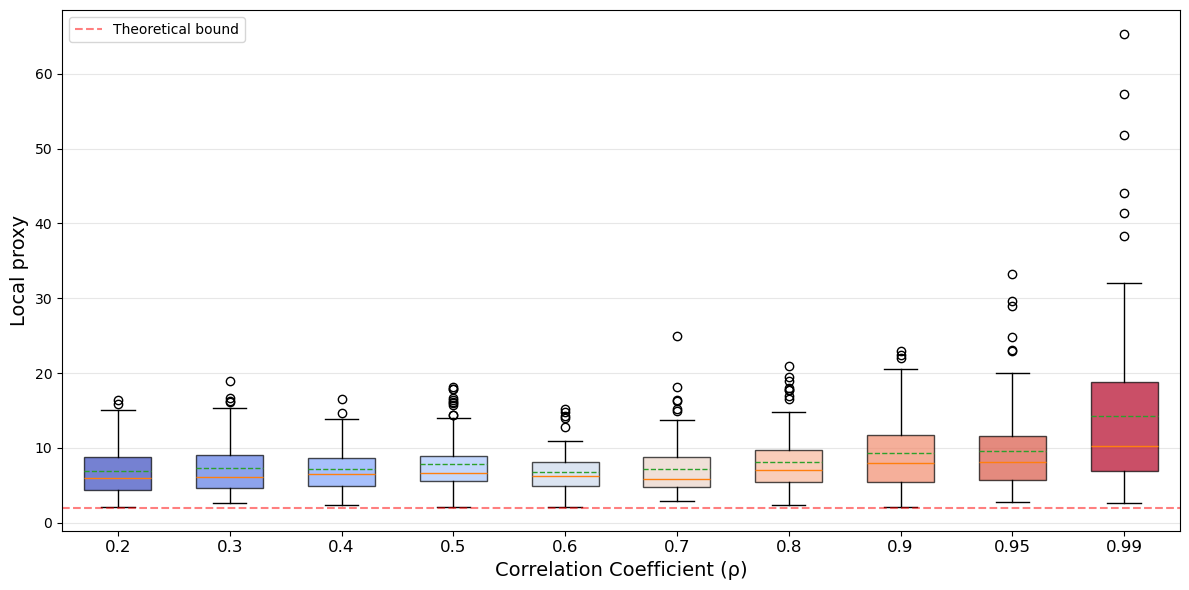

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import scipy.linalg
from tqdm import tqdm

# Set random seed for reproducibility
np.random.seed(42)

def create_diagonal_matrix(n, a):
    """Create an n*n matrix filled with zeros with diagonal elements set to value 'a'"""
    matrix = np.zeros((n, n))
    np.fill_diagonal(matrix, a)
    return matrix

def kl_mvn(to, fr):
    """Calculate KL(to||fr), where to and fr are pairs of means and covariance matrices"""
    m_to, S_to = to
    m_fr, S_fr = fr

    d = m_fr - m_to
    c, lower = scipy.linalg.cho_factor(S_fr)

    def solve(B):
        return scipy.linalg.cho_solve((c, lower), B)

    def logdet(S):
        return np.linalg.slogdet(S)[1]

    term1 = np.trace(solve(S_to))
    term2 = logdet(S_fr) - logdet(S_to)
    term3 = d.T @ solve(d)

    return (term1 + term2 + term3 - len(d)) / 2

def kl_mvn_stable(to, fr):
    """Calculate KL(to||fr) using numerically stable log-space computation"""
    m_to, S_to = to
    m_fr, S_fr = fr

    d = m_fr - m_to

    try:
        c, lower = scipy.linalg.cho_factor(S_fr)

        def solve(B):
            return scipy.linalg.cho_solve((c, lower), B)

        sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
        sign_to, logdet_to = np.linalg.slogdet(S_to)

        if sign_fr <= 0 or sign_to <= 0:
            return kl_mvn(to, fr)

        term1 = np.trace(solve(S_to))
        term2 = logdet_fr - logdet_to
        term3 = d.T @ solve(d)

        return (term1 + term2 + term3 - len(d)) / 2

    except np.linalg.LinAlgError:
        return kl_mvn(to, fr)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    KL between two matrix-normal distributions with row-covariance I_m:
        N(mu1, I_m ⊗ Sigma1)  vs  N(mu2, I_m ⊗ Sigma2)

    This reduces to sum of KLs of the row-wise MVNs.
    """
    m, n = mu1.shape
    total_kl = 0.0
    for i in range(m):
        row_mu1 = mu1[i, :]
        row_mu2 = mu2[i, :]
        total_kl += kl_mvn_stable((row_mu1, Sigma1), (row_mu2, Sigma2))
    return total_kl

def symmetric_matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """0.5 * (KL(P1||P2) + KL(P2||P1))"""
    kl1 = matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2)
    kl2 = matrix_kl_divergence(mu2, Sigma2, mu1, Sigma1)
    return 0.5 * (kl1 + kl2)

def generate_data_matrix(n, d, rho):
    cov_matrix = np.full((d, d), rho)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = np.random.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T  # (d, n)

def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    tau = 1 / sigma_squared
    return tau

def make_psd(matrix, min_eigenvalue=1e-10):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(eigenvalues, min_eigenvalue)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k, verbose=False):
    increment = 50
    max_iterations = 100000
    iteration = 0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def generate_psd_perturbation(original_matrix, epsilon):
    eigenvalues, eigenvectors = np.linalg.eigh(original_matrix)
    perturbed_eigenvalues = np.maximum(eigenvalues + epsilon, 1e-10)
    perturbed_matrix = eigenvectors @ np.diag(perturbed_eigenvalues) @ eigenvectors.T
    return perturbed_matrix

def compute_delta(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                  x, tau, d, n):
    Gamma_W = d * sigma_W + (mu_W.T @ mu_W)
    Gamma_z = n * sigma_z + (mu_z.T @ mu_z)
    Gamma_W_star = d * sigma_W_star + (mu_W_star.T @ mu_W_star)
    Gamma_z_star = n * sigma_z_star + (mu_z_star.T @ mu_z_star)

    mu_W_diff = mu_W - mu_W_star
    mu_z_diff = mu_z - mu_z_star

    term1 = tau * np.trace((mu_z_diff.T @ x.T) @ mu_W_diff)
    term2 = 0.5 * tau * np.trace((Gamma_W - Gamma_W_star) @ (Gamma_z - Gamma_z_star).T)
    delta = term1 - term2
    return delta

def compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
                  x, tau, d, n):
    sym_kl_W = symmetric_matrix_kl_divergence(mu_W, sigma_W, mu_W_ref, sigma_W_ref)
    sym_kl_z = symmetric_matrix_kl_divergence(mu_z, sigma_z, mu_z_ref, sigma_z_ref)

    threshold = 1e-300

    if sym_kl_W > threshold and sym_kl_z > threshold:
        delta = compute_delta(
            mu_W, sigma_W, mu_z, sigma_z,
            mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
            x, tau, d, n
        )

        log_delta = np.log(max(abs(delta), threshold))
        log_kl_W = np.log(sym_kl_W)
        log_kl_z = np.log(sym_kl_z)
        log_gcorr = log_delta - 0.5 * (log_kl_W + log_kl_z)
        gcorr = np.exp(log_gcorr)
        return gcorr, delta, sym_kl_W, sym_kl_z

    return None, None, sym_kl_W, sym_kl_z

def recurrence_iteration_with_tracking(mu_W, sigma_W, mu_z, sigma_z,
                                      Lambda, ELBOS, x, tau, d, n, k,
                                      mu_W_star, sigma_W_star, mu_z_star, sigma_z_star):
    increment = 50
    max_iterations = 100000
    iteration = 0

    initial_gcorr, _, _, _ = compute_gcorr(
        mu_W, sigma_W, mu_z, sigma_z,
        mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
        x, tau, d, n
    )
    max_gcorr = initial_gcorr if initial_gcorr is not None else 0.0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        if iteration % 50 == 0:
            gcorr, _, _, _ = compute_gcorr(
                mu_W, sigma_W, mu_z, sigma_z,
                mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                x, tau, d, n
            )
            if gcorr is not None and gcorr > max_gcorr:
                max_gcorr = gcorr

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS, max_gcorr, initial_gcorr


# =============================================================================
# UPDATED: SINGLE-DATASET WORKFLOW WITH m=50 PERTURBATIONS
# =============================================================================
def run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale=1e-15, m=100):
    """
    Workflow for one dataset:
      1) Run CAVI to convergence to get fixed point q*
      2) Generate m perturbations around q*
      3) For each perturbation, run CAVI back toward q* while tracking gcorr along the path
      4) Return:
         - max_gcorr = max over perturbations of (max gcorr along the trajectory)
         - initial_gcorr = the initial gcorr corresponding to the perturbation that attained max_gcorr
         - also returns lists for diagnostics
    """
    # Generate dataset
    x = generate_data_matrix(n, d, rho)
    tau = estimate_tau_ppca(x, k)
    Lambda = alpha * np.eye(k)

    # Initial random start -> converge to fixed point
    mu_W = np.random.randn(d, k)
    sigma_W = np.eye(k)
    mu_z = np.random.randn(n, k)
    sigma_z = np.eye(k)
    ELBOS = []

    mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS = recurrence_iteration(
        mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k
    )

    # Repeat m perturbations
    initial_gcorrs = []
    max_gcorrs = []
    kl_W_list = []
    kl_z_list = []
    n_iterations_second_list = []

    for _ in range(m):
        mu_W_pert = mu_W_star + perturbation_scale * np.random.randn(*mu_W_star.shape)
        mu_z_pert = mu_z_star + perturbation_scale * np.random.randn(*mu_z_star.shape)
        sigma_W_pert = generate_psd_perturbation(sigma_W_star, perturbation_scale)
        sigma_z_pert = generate_psd_perturbation(sigma_z_star, perturbation_scale)

       
        kl_W_pert_to_final = matrix_kl_divergence(mu_W_star, sigma_W_star, mu_W_pert, sigma_W_pert)
        kl_z_pert_to_final = matrix_kl_divergence(mu_z_star, sigma_z_star, mu_z_pert, sigma_z_pert)

        ELBOS_new = []
        _, _, _, _, ELBOS_new, max_gcorr_i, init_gcorr_i = recurrence_iteration_with_tracking(
            mu_W_pert, sigma_W_pert, mu_z_pert, sigma_z_pert,
            Lambda, ELBOS_new, x, tau, d, n, k,
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star
        )

        initial_gcorrs.append(init_gcorr_i)
        max_gcorrs.append(max_gcorr_i)
        kl_W_list.append(kl_W_pert_to_final)
        kl_z_list.append(kl_z_pert_to_final)
        n_iterations_second_list.append(len(ELBOS_new))

    # Choose "best perturbation" = one achieving overall max_gcorr
    if len(max_gcorrs) == 0:
        overall_max_gcorr = None
        best_initial_gcorr = None
        best_kl_W = None
        best_kl_z = None
        best_n_iter_second = None
    else:
        best_idx = int(np.argmax(max_gcorrs))
        overall_max_gcorr = max_gcorrs[best_idx]
        best_initial_gcorr = initial_gcorrs[best_idx]
        best_kl_W = kl_W_list[best_idx]
        best_kl_z = kl_z_list[best_idx]
        best_n_iter_second = n_iterations_second_list[best_idx]

    return {
        'tau': tau,

        # "best" perturbation scalars for backward compatibility 
        'initial_gcorr': best_initial_gcorr,
        'max_gcorr': overall_max_gcorr,
        'kl_W_pert_to_final': best_kl_W,
        'kl_z_pert_to_final': best_kl_z,
        'n_iterations_first': len(ELBOS),
        'n_iterations_second': best_n_iter_second,

        # diagnostics: lists over all m perturbations
        'initial_gcorrs': initial_gcorrs,
        'max_gcorrs': max_gcorrs,
        'kl_W_pert_to_final_list': kl_W_list,
        'kl_z_pert_to_final_list': kl_z_list,
        'n_iterations_second_list': n_iterations_second_list,
        'm': m,
    }


# =============================================================================
# Example usage and testing
# =============================================================================
if __name__ == "__main__":
    # Test the KL divergence functions
    print("Testing KL divergence functions...")

    mu1 = np.array([[1, 2], [3, 4]])
    mu2 = np.array([[1.1, 2.1], [3.1, 4.1]])
    sigma1 = np.eye(2)
    sigma2 = 1.1 * np.eye(2)

    kl_div = matrix_kl_divergence(mu1, sigma1, mu2, sigma2)
    sym_kl_div = symmetric_matrix_kl_divergence(mu1, sigma1, mu2, sigma2)

    print(f"KL divergence: {kl_div:.6f}")
    print(f"Symmetric KL divergence: {sym_kl_div:.6f}")

    # -------------------------------------------------------------------------
    # Single rho quick run (kept as in  code; now each dataset uses m=50)
    # -------------------------------------------------------------------------
    d, n, k = 2, 20, 1
    rho, alpha, N = 0.9, 1.0, 100
    perturbation_scale = 1e-7

    results = []
    initial_gcorrs = []
    max_gcorrs = []
    kl_W_values = []
    kl_z_values = []

    for i in tqdm(range(N), desc="Processing datasets"):
        result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale, m=50)
        results.append(result)

        if result['initial_gcorr'] is None:
            print(f"Dataset {i}: initial_gcorr is None")
        if result['max_gcorr'] is None:
            print(f"Dataset {i}: max_gcorr is None")

        initial_gcorrs.append(result['initial_gcorr'])
        max_gcorrs.append(result['max_gcorr'])
        kl_W_values.append(result['kl_W_pert_to_final'])
        kl_z_values.append(result['kl_z_pert_to_final'])

    # Filter out None values before computing statistics
    initial_gcorrs_clean = [x for x in initial_gcorrs if x is not None]
    max_gcorrs_clean = [x for x in max_gcorrs if x is not None]

    print(f"\nValid computations: {len(initial_gcorrs_clean)}/{len(initial_gcorrs)}")

    print("\n" + "=" * 60)
    print("KL DIVERGENCE STATISTICS (best perturbation per dataset)")
    print("=" * 60)

    def format_small_number(x):
        if x == 0:
            return "0.0"
        elif x < 1e-6:
            return f"{x:.12e}"
        else:
            return f"{x:.12f}"

    # Handle potential None in KL lists (if any)
    kl_W_clean = [x for x in kl_W_values if x is not None]
    kl_z_clean = [x for x in kl_z_values if x is not None]

    if kl_W_clean:
        print("KL(q_W_final||q_W_perturb):")
        print(f"  Mean:   {format_small_number(np.mean(kl_W_clean))}")
        print(f"  Std:    {format_small_number(np.std(kl_W_clean))}")
        print(f"  Min:    {format_small_number(np.min(kl_W_clean))}")
        print(f"  Max:    {format_small_number(np.max(kl_W_clean))}")
        print(f"  Median: {format_small_number(np.median(kl_W_clean))}")
    else:
        print("KL(q_W_final||q_W_perturb): No valid values")

    if kl_z_clean:
        print("\nKL(q_z_final||q_z_perturb):")
        print(f"  Mean:   {format_small_number(np.mean(kl_z_clean))}")
        print(f"  Std:    {format_small_number(np.std(kl_z_clean))}")
        print(f"  Min:    {format_small_number(np.min(kl_z_clean))}")
        print(f"  Max:    {format_small_number(np.max(kl_z_clean))}")
        print(f"  Median: {format_small_number(np.median(kl_z_clean))}")
    else:
        print("KL(q_z_final||q_z_perturb): No valid values")

    print("\n" + "=" * 60)
    print("GCORR STATISTICS (best perturbation per dataset)")
    print("=" * 60)

    if initial_gcorrs_clean:
        print(
            f"Initial GCorr: Mean={np.mean(initial_gcorrs_clean):.4f}, Std={np.std(initial_gcorrs_clean):.4f}, "
            f"Min={np.min(initial_gcorrs_clean):.4f}, Max={np.max(initial_gcorrs_clean):.4f}"
        )
    else:
        print("Initial GCorr: No valid values")

    if max_gcorrs_clean:
        print(
            f"Max GCorr:     Mean={np.mean(max_gcorrs_clean):.4f}, Std={np.std(max_gcorrs_clean):.4f}, "
            f"Min={np.min(max_gcorrs_clean):.4f}, Max={np.max(max_gcorrs_clean):.4f}"
        )
    else:
        print("Max GCorr: No valid values")

    ratios = [m / i for m, i in zip(max_gcorrs_clean, initial_gcorrs_clean) if i is not None and i > 0]
    if ratios:
        print(f"Ratio (Max/Init): Mean={np.mean(ratios):.4f}, Std={np.std(ratios):.4f}")
    else:
        print("Ratio (Max/Init): No valid ratios")

    if max_gcorrs_clean:
        plt.figure(figsize=(10, 6))
        box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][0].set_alpha(0.7)
        plt.title('Distribution of Maximum GCorr Values', fontsize=14, fontweight='bold')
        plt.ylabel('Max GCorr', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid max GCorr values to plot")


    # =============================================================================
    # ANALYSIS ACROSS MULTIPLE RHO VALUES (unchanged except m=50 is used)
    # =============================================================================
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    all_max_gcorrs_by_rho = []

    # Parameters
    d = 3
    n = 20
    k = 2
    alpha = 1.0
    N_per_rho = 100
    perturbation_scale = 1e-7
    m = 50  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    print("Running experiments across multiple rho values...")

    for rho in tqdm(rho_values, desc="Varying rho"):
        max_gcorrs_rho = []
        for _ in range(N_per_rho):
            result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale, m=m)
            max_gcorrs_rho.append(result['max_gcorr'])
        all_max_gcorrs_by_rho.append(max_gcorrs_rho)

    # Plot box plot ( consistent style)
    plt.figure(figsize=(12, 6))

    box = plt.boxplot(all_max_gcorrs_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=12)
    plt.xlabel('Correlation Coefficient (ρ)', fontsize=14)

    plt.ylabel('Local proxy', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')

    plt.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Theoretical bound')
    plt.legend()

    plt.tight_layout()
    plt.savefig("maxGCorrboxplot_30_100.pdf", format="pdf", bbox_inches="tight")
    plt.show()


Testing KL divergence functions...
KL divergence: 0.026984
Symmetric KL divergence: 0.028182


Processing datasets: 100%|████████████████████| 100/100 [00:52<00:00,  1.91it/s]


Valid computations: 100/100

KL DIVERGENCE STATISTICS (best perturbation per dataset)
KL(q_W_final||q_W_perturb):
  Mean:   3.252604408033e-10
  Std:    2.765943769060e-10
  Min:    7.867373419401e-11
  Max:    1.678783556613e-09
  Median: 2.491552519857e-10

KL(q_z_final||q_z_perturb):
  Mean:   3.534935011373e-11
  Std:    4.346816670414e-11
  Min:    2.995048653531e-12
  Max:    3.338730403257e-10
  Median: 2.538858012713e-11

GCORR STATISTICS (best perturbation per dataset)
Initial GCorr: Mean=0.1013, Std=0.0848, Min=0.0001, Max=0.3124
Max GCorr:     Mean=2.6873, Std=3.1666, Min=0.1194, Max=13.9898
Ratio (Max/Init): Mean=875.1360, Std=6567.8982



/var/folders/2x/1nbr4z456238x43xpmlql0nm0000gn/T/ipykernel_53473/325996573.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)


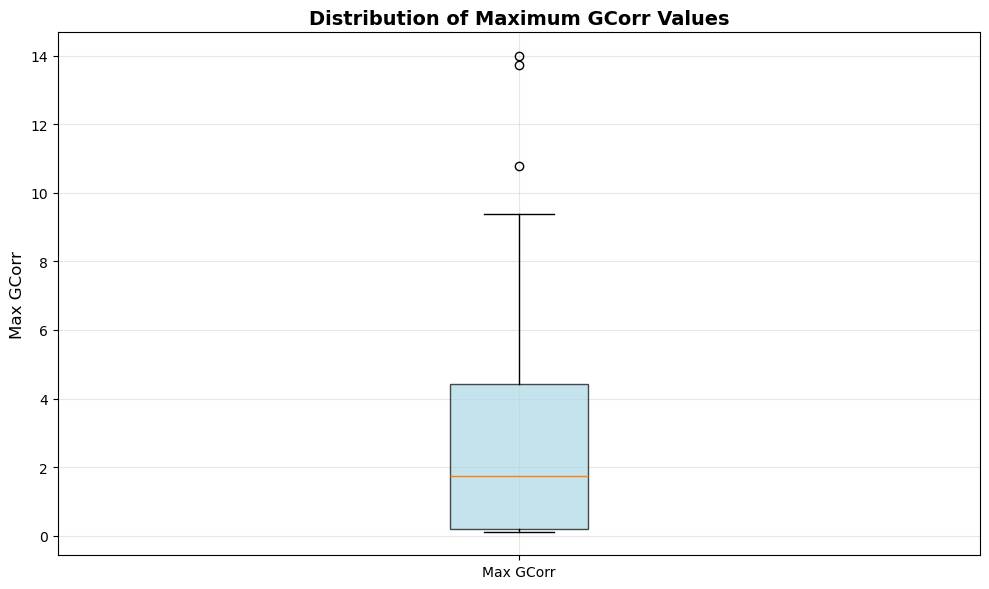

Running experiments across multiple rho values...


Varying rho: 100%|████████████████████████████████| 8/8 [06:54<00:00, 51.85s/it]


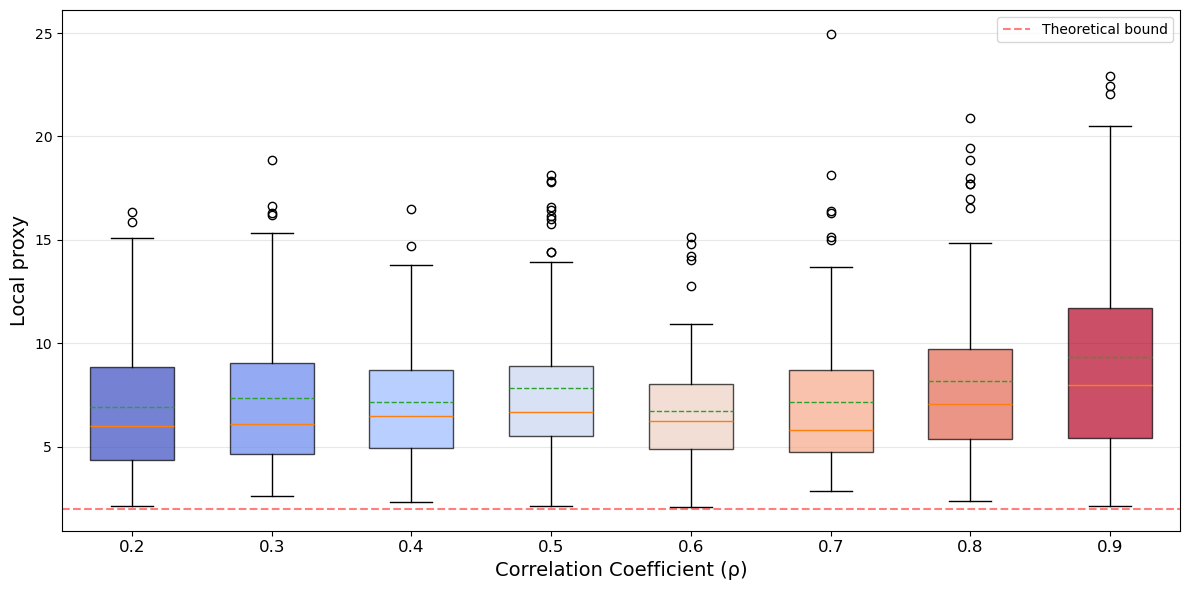

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import scipy.linalg
from tqdm import tqdm

# Set random seed for reproducibility
np.random.seed(42)

def create_diagonal_matrix(n, a):
    """Create an n*n matrix filled with zeros with diagonal elements set to value 'a'"""
    matrix = np.zeros((n, n))
    np.fill_diagonal(matrix, a)
    return matrix

def kl_mvn(to, fr):
    """Calculate KL(to||fr), where to and fr are pairs of means and covariance matrices"""
    m_to, S_to = to
    m_fr, S_fr = fr

    d = m_fr - m_to
    c, lower = scipy.linalg.cho_factor(S_fr)

    def solve(B):
        return scipy.linalg.cho_solve((c, lower), B)

    def logdet(S):
        return np.linalg.slogdet(S)[1]

    term1 = np.trace(solve(S_to))
    term2 = logdet(S_fr) - logdet(S_to)
    term3 = d.T @ solve(d)

    return (term1 + term2 + term3 - len(d)) / 2

def kl_mvn_stable(to, fr):
    """Calculate KL(to||fr) using numerically stable log-space computation"""
    m_to, S_to = to
    m_fr, S_fr = fr

    d = m_fr - m_to

    try:
        c, lower = scipy.linalg.cho_factor(S_fr)

        def solve(B):
            return scipy.linalg.cho_solve((c, lower), B)

        sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
        sign_to, logdet_to = np.linalg.slogdet(S_to)

        if sign_fr <= 0 or sign_to <= 0:
            return kl_mvn(to, fr)

        term1 = np.trace(solve(S_to))
        term2 = logdet_fr - logdet_to
        term3 = d.T @ solve(d)

        return (term1 + term2 + term3 - len(d)) / 2

    except np.linalg.LinAlgError:
        return kl_mvn(to, fr)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    KL between two matrix-normal distributions with row-covariance I_m:
        N(mu1, I_m ⊗ Sigma1)  vs  N(mu2, I_m ⊗ Sigma2)

    This reduces to sum of KLs of the row-wise MVNs.
    """
    m, n = mu1.shape
    total_kl = 0.0
    for i in range(m):
        row_mu1 = mu1[i, :]
        row_mu2 = mu2[i, :]
        total_kl += kl_mvn_stable((row_mu1, Sigma1), (row_mu2, Sigma2))
    return total_kl

def symmetric_matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """0.5 * (KL(P1||P2) + KL(P2||P1))"""
    kl1 = matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2)
    kl2 = matrix_kl_divergence(mu2, Sigma2, mu1, Sigma1)
    return 0.5 * (kl1 + kl2)

def generate_data_matrix(n, d, rho):
    cov_matrix = np.full((d, d), rho)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = np.random.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T  # (d, n)

def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    tau = 1 / sigma_squared
    return tau

def make_psd(matrix, min_eigenvalue=1e-10):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(eigenvalues, min_eigenvalue)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k, verbose=False):
    increment = 50
    max_iterations = 100000
    iteration = 0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def generate_psd_perturbation(original_matrix, epsilon):
    eigenvalues, eigenvectors = np.linalg.eigh(original_matrix)
    perturbed_eigenvalues = np.maximum(eigenvalues + epsilon, 1e-10)
    perturbed_matrix = eigenvectors @ np.diag(perturbed_eigenvalues) @ eigenvectors.T
    return perturbed_matrix

def compute_delta(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                  x, tau, d, n):
    Gamma_W = d * sigma_W + (mu_W.T @ mu_W)
    Gamma_z = n * sigma_z + (mu_z.T @ mu_z)
    Gamma_W_star = d * sigma_W_star + (mu_W_star.T @ mu_W_star)
    Gamma_z_star = n * sigma_z_star + (mu_z_star.T @ mu_z_star)

    mu_W_diff = mu_W - mu_W_star
    mu_z_diff = mu_z - mu_z_star

    term1 = tau * np.trace((mu_z_diff.T @ x.T) @ mu_W_diff)
    term2 = 0.5 * tau * np.trace((Gamma_W - Gamma_W_star) @ (Gamma_z - Gamma_z_star).T)
    delta = term1 - term2
    return delta

def compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
                  x, tau, d, n):
    sym_kl_W = symmetric_matrix_kl_divergence(mu_W, sigma_W, mu_W_ref, sigma_W_ref)
    sym_kl_z = symmetric_matrix_kl_divergence(mu_z, sigma_z, mu_z_ref, sigma_z_ref)

    threshold = 1e-300

    if sym_kl_W > threshold and sym_kl_z > threshold:
        delta = compute_delta(
            mu_W, sigma_W, mu_z, sigma_z,
            mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
            x, tau, d, n
        )

        log_delta = np.log(max(abs(delta), threshold))
        log_kl_W = np.log(sym_kl_W)
        log_kl_z = np.log(sym_kl_z)
        log_gcorr = log_delta - 0.5 * (log_kl_W + log_kl_z)
        gcorr = np.exp(log_gcorr)
        return gcorr, delta, sym_kl_W, sym_kl_z

    return None, None, sym_kl_W, sym_kl_z

def recurrence_iteration_with_tracking(mu_W, sigma_W, mu_z, sigma_z,
                                      Lambda, ELBOS, x, tau, d, n, k,
                                      mu_W_star, sigma_W_star, mu_z_star, sigma_z_star):
    increment = 50
    max_iterations = 100000
    iteration = 0

    initial_gcorr, _, _, _ = compute_gcorr(
        mu_W, sigma_W, mu_z, sigma_z,
        mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
        x, tau, d, n
    )
    max_gcorr = initial_gcorr if initial_gcorr is not None else 0.0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        if iteration % 50 == 0:
            gcorr, _, _, _ = compute_gcorr(
                mu_W, sigma_W, mu_z, sigma_z,
                mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                x, tau, d, n
            )
            if gcorr is not None and gcorr > max_gcorr:
                max_gcorr = gcorr

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            sign_W, logdet_W = np.linalg.slogdet(sigma_W)
            sign_z, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS, max_gcorr, initial_gcorr


# =============================================================================
# UPDATED: SINGLE-DATASET WORKFLOW WITH m=50 PERTURBATIONS
# =============================================================================
def run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale=1e-15, m=1000000):
    """
    Workflow for one dataset:
      1) Run CAVI to convergence to get fixed point q*
      2) Generate m perturbations around q*
      3) For each perturbation, run CAVI back toward q* while tracking gcorr along the path
      4) Return:
         - max_gcorr = max over perturbations of (max gcorr along the trajectory)
         - initial_gcorr = the initial gcorr corresponding to the perturbation that attained max_gcorr
         - also returns lists for diagnostics
    """
    # Generate dataset
    x = generate_data_matrix(n, d, rho)
    tau = estimate_tau_ppca(x, k)
    Lambda = alpha * np.eye(k)

    # Initial random start -> converge to fixed point
    mu_W = np.random.randn(d, k)
    sigma_W = np.eye(k)
    mu_z = np.random.randn(n, k)
    sigma_z = np.eye(k)
    ELBOS = []

    mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS = recurrence_iteration(
        mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k
    )

    # Repeat m perturbations
    initial_gcorrs = []
    max_gcorrs = []
    kl_W_list = []
    kl_z_list = []
    n_iterations_second_list = []

    for _ in range(m):
        mu_W_pert = mu_W_star + perturbation_scale * np.random.randn(*mu_W_star.shape)
        mu_z_pert = mu_z_star + perturbation_scale * np.random.randn(*mu_z_star.shape)
        sigma_W_pert = generate_psd_perturbation(sigma_W_star, perturbation_scale)
        sigma_z_pert = generate_psd_perturbation(sigma_z_star, perturbation_scale)

        # Keep EXACT order 
        kl_W_pert_to_final = matrix_kl_divergence(mu_W_star, sigma_W_star, mu_W_pert, sigma_W_pert)
        kl_z_pert_to_final = matrix_kl_divergence(mu_z_star, sigma_z_star, mu_z_pert, sigma_z_pert)

        ELBOS_new = []
        _, _, _, _, ELBOS_new, max_gcorr_i, init_gcorr_i = recurrence_iteration_with_tracking(
            mu_W_pert, sigma_W_pert, mu_z_pert, sigma_z_pert,
            Lambda, ELBOS_new, x, tau, d, n, k,
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star
        )

        initial_gcorrs.append(init_gcorr_i)
        max_gcorrs.append(max_gcorr_i)
        kl_W_list.append(kl_W_pert_to_final)
        kl_z_list.append(kl_z_pert_to_final)
        n_iterations_second_list.append(len(ELBOS_new))

    # Choose "best perturbation" = one achieving overall max_gcorr
    if len(max_gcorrs) == 0:
        overall_max_gcorr = None
        best_initial_gcorr = None
        best_kl_W = None
        best_kl_z = None
        best_n_iter_second = None
    else:
        best_idx = int(np.argmax(max_gcorrs))
        overall_max_gcorr = max_gcorrs[best_idx]
        best_initial_gcorr = initial_gcorrs[best_idx]
        best_kl_W = kl_W_list[best_idx]
        best_kl_z = kl_z_list[best_idx]
        best_n_iter_second = n_iterations_second_list[best_idx]

    return {
        'tau': tau,

        # "best" perturbation scalars for backward compatibility
        'initial_gcorr': best_initial_gcorr,
        'max_gcorr': overall_max_gcorr,
        'kl_W_pert_to_final': best_kl_W,
        'kl_z_pert_to_final': best_kl_z,
        'n_iterations_first': len(ELBOS),
        'n_iterations_second': best_n_iter_second,

        # diagnostics: lists over all m perturbations
        'initial_gcorrs': initial_gcorrs,
        'max_gcorrs': max_gcorrs,
        'kl_W_pert_to_final_list': kl_W_list,
        'kl_z_pert_to_final_list': kl_z_list,
        'n_iterations_second_list': n_iterations_second_list,
        'm': m,
    }


# =============================================================================
# Example usage and testing
# =============================================================================
if __name__ == "__main__":
    # Test the KL divergence functions
    print("Testing KL divergence functions...")

    mu1 = np.array([[1, 2], [3, 4]])
    mu2 = np.array([[1.1, 2.1], [3.1, 4.1]])
    sigma1 = np.eye(2)
    sigma2 = 1.1 * np.eye(2)

    kl_div = matrix_kl_divergence(mu1, sigma1, mu2, sigma2)
    sym_kl_div = symmetric_matrix_kl_divergence(mu1, sigma1, mu2, sigma2)

    print(f"KL divergence: {kl_div:.6f}")
    print(f"Symmetric KL divergence: {sym_kl_div:.6f}")

    # -------------------------------------------------------------------------
    # Single rho quick run 
    # -------------------------------------------------------------------------
    d, n, k = 2, 20, 1
    rho, alpha, N = 0.9, 1.0, 100
    perturbation_scale = 1e-7

    results = []
    initial_gcorrs = []
    max_gcorrs = []
    kl_W_values = []
    kl_z_values = []

    for i in tqdm(range(N), desc="Processing datasets"):
        result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale, m=50)
        results.append(result)

        if result['initial_gcorr'] is None:
            print(f"Dataset {i}: initial_gcorr is None")
        if result['max_gcorr'] is None:
            print(f"Dataset {i}: max_gcorr is None")

        initial_gcorrs.append(result['initial_gcorr'])
        max_gcorrs.append(result['max_gcorr'])
        kl_W_values.append(result['kl_W_pert_to_final'])
        kl_z_values.append(result['kl_z_pert_to_final'])

    # Filter out None values before computing statistics
    initial_gcorrs_clean = [x for x in initial_gcorrs if x is not None]
    max_gcorrs_clean = [x for x in max_gcorrs if x is not None]

    print(f"\nValid computations: {len(initial_gcorrs_clean)}/{len(initial_gcorrs)}")

    print("\n" + "=" * 60)
    print("KL DIVERGENCE STATISTICS (best perturbation per dataset)")
    print("=" * 60)

    def format_small_number(x):
        if x == 0:
            return "0.0"
        elif x < 1e-6:
            return f"{x:.12e}"
        else:
            return f"{x:.12f}"

    # Handle potential None in KL lists (if any)
    kl_W_clean = [x for x in kl_W_values if x is not None]
    kl_z_clean = [x for x in kl_z_values if x is not None]

    if kl_W_clean:
        print("KL(q_W_final||q_W_perturb):")
        print(f"  Mean:   {format_small_number(np.mean(kl_W_clean))}")
        print(f"  Std:    {format_small_number(np.std(kl_W_clean))}")
        print(f"  Min:    {format_small_number(np.min(kl_W_clean))}")
        print(f"  Max:    {format_small_number(np.max(kl_W_clean))}")
        print(f"  Median: {format_small_number(np.median(kl_W_clean))}")
    else:
        print("KL(q_W_final||q_W_perturb): No valid values")

    if kl_z_clean:
        print("\nKL(q_z_final||q_z_perturb):")
        print(f"  Mean:   {format_small_number(np.mean(kl_z_clean))}")
        print(f"  Std:    {format_small_number(np.std(kl_z_clean))}")
        print(f"  Min:    {format_small_number(np.min(kl_z_clean))}")
        print(f"  Max:    {format_small_number(np.max(kl_z_clean))}")
        print(f"  Median: {format_small_number(np.median(kl_z_clean))}")
    else:
        print("KL(q_z_final||q_z_perturb): No valid values")

    print("\n" + "=" * 60)
    print("GCORR STATISTICS (best perturbation per dataset)")
    print("=" * 60)

    if initial_gcorrs_clean:
        print(
            f"Initial GCorr: Mean={np.mean(initial_gcorrs_clean):.4f}, Std={np.std(initial_gcorrs_clean):.4f}, "
            f"Min={np.min(initial_gcorrs_clean):.4f}, Max={np.max(initial_gcorrs_clean):.4f}"
        )
    else:
        print("Initial GCorr: No valid values")

    if max_gcorrs_clean:
        print(
            f"Max GCorr:     Mean={np.mean(max_gcorrs_clean):.4f}, Std={np.std(max_gcorrs_clean):.4f}, "
            f"Min={np.min(max_gcorrs_clean):.4f}, Max={np.max(max_gcorrs_clean):.4f}"
        )
    else:
        print("Max GCorr: No valid values")

    ratios = [m / i for m, i in zip(max_gcorrs_clean, initial_gcorrs_clean) if i is not None and i > 0]
    if ratios:
        print(f"Ratio (Max/Init): Mean={np.mean(ratios):.4f}, Std={np.std(ratios):.4f}")
    else:
        print("Ratio (Max/Init): No valid ratios")

    if max_gcorrs_clean:
        plt.figure(figsize=(10, 6))
        box_plot = plt.boxplot([max_gcorrs_clean], labels=['Max GCorr'], patch_artist=True)
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][0].set_alpha(0.7)
        plt.title('Distribution of Maximum GCorr Values', fontsize=14, fontweight='bold')
        plt.ylabel('Max GCorr', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid max GCorr values to plot")


    # =============================================================================
    # ANALYSIS ACROSS MULTIPLE RHO VALUES (unchanged except m=50 is used)
    # =============================================================================
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7,0.8,0.9]
    all_max_gcorrs_by_rho = []

    # Parameters
    d = 3
    n = 20
    k = 2
    alpha = 1.0
    N_per_rho = 100
    perturbation_scale = 1e-7
    m = 50  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    print("Running experiments across multiple rho values...")

    for rho in tqdm(rho_values, desc="Varying rho"):
        max_gcorrs_rho = []
        for _ in range(N_per_rho):
            result = run_single_dataset_workflow(n, d, k, rho, alpha, perturbation_scale, m=m)
            max_gcorrs_rho.append(result['max_gcorr'])
        all_max_gcorrs_by_rho.append(max_gcorrs_rho)

    # Plot box plot (consistent style)
    plt.figure(figsize=(12, 6))

    box = plt.boxplot(all_max_gcorrs_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=12)
    plt.xlabel('Correlation Coefficient (ρ)', fontsize=14)

    plt.ylabel('Local proxy', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')

    plt.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Theoretical bound')
    plt.legend()

    plt.tight_layout()
    plt.savefig("maxGCorrboxplot_40_mil.pdf", format="pdf", bbox_inches="tight")
    plt.show()


Computing m_j (= M_i) distributions across rho values...


rho loop:  25%|████████▊                          | 2/8 [00:00<00:01,  4.56it/s]

rho=0.2: successful 100/100
rho=0.3: successful 100/100


rho loop:  38%|█████████████▏                     | 3/8 [00:00<00:01,  4.35it/s]

rho=0.4: successful 100/100
rho=0.5: successful 100/100


...

rho=0.7: successful 100/100


rho loop:  88%|██████████████████████████████▋    | 7/8 [00:02<00:00,  2.59it/s]

rho=0.8: successful 100/100


rho loop: 100%|███████████████████████████████████| 8/8 [00:03<00:00,  2.61it/s]

rho=0.9: successful 100/100


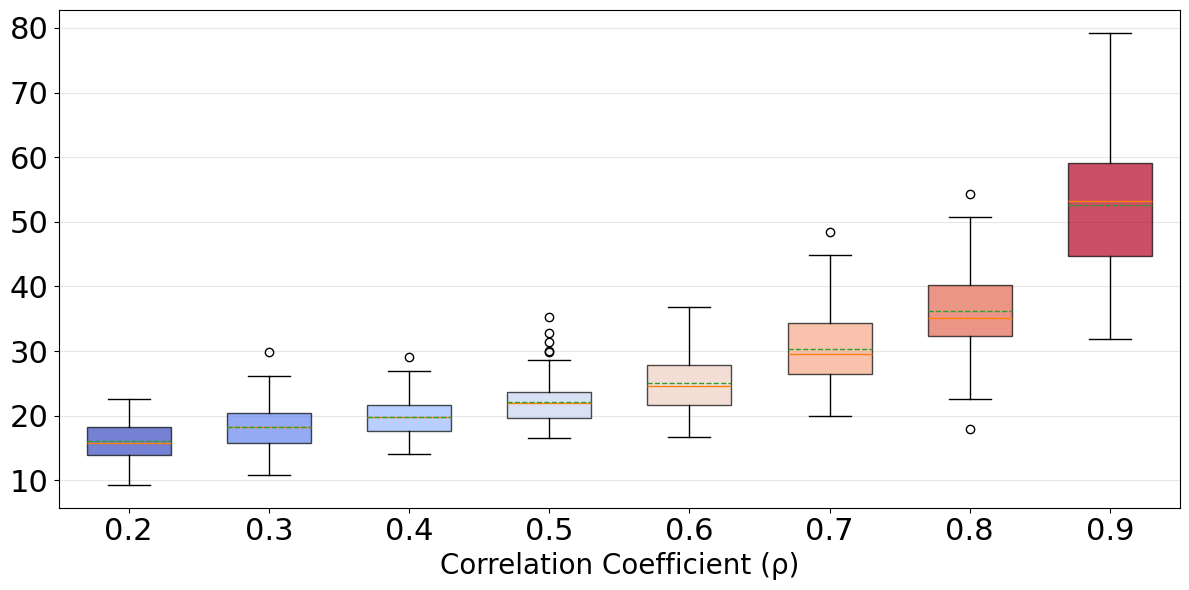


Summary Statistics by ρ value:
------------------------------------------------------------------------
ρ      Nsucc  Mean         Median       Std          Min          Max         
------------------------------------------------------------------------
0.2    100    16.0136      15.7425      2.8360       9.2637       22.6563     
0.3    100    18.2413      18.2647      3.1776       10.8457      29.7941     
0.4    100    19.7245      19.7406      2.9237       14.0337      29.0092     
0.5    100    22.0942      21.9998      3.5674       16.5517      35.2314     
0.6    100    25.1301      24.6740      4.4678       16.6941      36.8026     
0.7    100    30.2781      29.5266      5.4649       20.0262      48.4936     
0.8    100    36.2522      35.0815      6.5065       17.9438      54.3510     
0.9    100    52.6121      53.1548      10.5756      31.9399      79.2724     


In [7]:
# =============================================================================
# CODE 2 (Upper-bound proxy via M_i) — CLEAN + uses m_i language + robust plotting
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import eigh
from tqdm import tqdm

# -----------------------------------------------------------------------------
# IMPORTANT: dataset control
# - For each fixed rho, we generate EXACTLY N_per_rho datasets x_rho^j using a
#   dedicated RNG seeded by (BASE_DATASET_SEED, rho).
# -----------------------------------------------------------------------------
BASE_DATASET_SEED = 41

def _seed_for_rho(rho: float, base_seed: int = BASE_DATASET_SEED) -> int:
    # stable mapping rho -> integer key (0.2 -> 200, etc.)
    key = int(round(rho * 1000))
    return (base_seed + 100000 * key) % (2**32 - 1)

def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    """Generate one dataset x of shape (d, n) using ONLY rng."""
    cov_matrix = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = rng.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T  # (d, n)

def make_datasets_for_rho(n: int, d: int, rho: float, N: int, base_seed: int = BASE_DATASET_SEED):
    """Return list [x_rho^1, ..., x_rho^N], deterministically."""
    rng = np.random.default_rng(_seed_for_rho(rho, base_seed))
    return [generate_data_matrix_rng(rng, n, d, rho) for _ in range(N)]

# -----------------------------------------------------------------------------
# PPCA tau estimate
# -----------------------------------------------------------------------------
def estimate_tau_ppca(x, k):
    """Estimate tau using PPCA MLE approach."""
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-8
    return 1.0 / sigma_squared

# -----------------------------------------------------------------------------
# CAVI recurrence 
# -----------------------------------------------------------------------------
def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    max_iterations = 100000
    iteration = 0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)

        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)

        mu_z = tau * (x.T @ mu_W) @ sigma_z

        # ELBO 
        B = (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) @ (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)
        C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
        D = np.trace(mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)

        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)
        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")

        ELBO = (
            tau * np.trace((mu_W @ mu_z.T) @ x.T)
            - (tau / 2) * np.trace(B)
            - 0.5 * C
            - 0.5 * D
            + 0.5 * d * logdet_W
            + 0.5 * n * logdet_z
        )
        ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

# -----------------------------------------------------------------------------
# M_i computation 
# -----------------------------------------------------------------------------
def compute_M_i(x, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau, n, d):
    gamma0 = 0.25 * (1 + math.e**(-1))

    norm_sigma_W = np.linalg.norm(sigma_W_star, ord="fro")
    norm_sigma_z = np.linalg.norm(sigma_z_star, ord="fro")
    norm_mu_W = np.linalg.norm(mu_W_star, ord="fro")
    norm_mu_z = np.linalg.norm(mu_z_star, ord="fro")
    norm_x = np.linalg.norm(x, ord="fro")

    key_term_star = norm_x + 2 * norm_mu_W * norm_mu_z

    term1 = ((norm_sigma_W * norm_sigma_z) ** 0.5 * key_term_star) / gamma0
    term2 = 2 * math.e * (norm_sigma_W * norm_sigma_z) * math.sqrt(n * d)
    term3 = (norm_sigma_W * (norm_sigma_z ** 0.5) * math.sqrt(2 * d * math.e) * norm_mu_z) / (gamma0**0.5)
    term4 = ((norm_sigma_W ** 0.5) * norm_sigma_z * math.sqrt(2 * n * math.e) * norm_mu_W) / (gamma0**0.5)

    return tau * max(term1, term2, term3, term4)

# -----------------------------------------------------------------------------
# For one fixed rho: compute m_i for j=1..N datasets
# -----------------------------------------------------------------------------
def compute_m_values_for_rho(n, d, k, rho, N_per_rho=100, base_seed=BASE_DATASET_SEED):
    """
    For fixed rho:
      - generate datasets x_rho^j, j=1..N_per_rho (deterministic)
      - run CAVI to get fixed point (mu_W*,sigma_W*,mu_z*,sigma_z*)
      - compute m_j := M(x_rho^j, q* (x_rho^j))
    Returns:
      m_values: list of length <= N_per_rho (skips failures)
    """
    datasets = make_datasets_for_rho(n, d, rho, N_per_rho, base_seed=base_seed)

    
    mu_W0 = np.full((d, k), 0.1)
    sigma_W0 = np.eye(k)
    mu_z0 = np.full((n, k), 0.1)
    sigma_z0 = np.eye(k)

    # Lambda 
    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))
    Lambda = np.diag(diagonal_elements[:k])

    m_values = []

    for x_j in datasets:
        tau_j = estimate_tau_ppca(x_j, k)
        ELBOS = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, _ = recurrence_iteration(
                mu_W0.copy(), sigma_W0.copy(), mu_z0.copy(), sigma_z0.copy(),
                Lambda, ELBOS, x_j, tau_j, d, n, k
            )
            m_j = compute_M_i(x_j, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_j, n, d)
            if np.isfinite(m_j):
                m_values.append(m_j)
        except Exception:
            # skip failures
            continue

    return m_values

# -----------------------------------------------------------------------------
# Compare across rhos: boxplot of {m_j} distributions
# -----------------------------------------------------------------------------
def compare_rho_values():
    # Fixed parameters 
    n, d, k = 20, 3, 2
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    N_per_rho = 100

    all_m_values = []

    print("Computing m_j (= M_i) distributions across rho values...")
    for rho in tqdm(rho_values, desc="rho loop"):
        m_vals = compute_m_values_for_rho(
            n, d, k, rho,
            N_per_rho=N_per_rho,
            base_seed=BASE_DATASET_SEED
        )
        all_m_values.append(m_vals)
        print(f"rho={rho}: successful {len(m_vals)}/{N_per_rho}")

    # If some rho has empty list, matplotlib will draw nothing for that box.
    # We print a warning 
    for rho, m_vals in zip(rho_values, all_m_values):
        if len(m_vals) == 0:
            print(f"WARNING: rho={rho} produced 0 valid m_j values (box will be empty).")

    # Boxplot 
    plt.figure(figsize=(12, 6))
    box_plot = plt.boxplot(all_m_values, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box_plot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
    plt.yticks(fontsize=22) 
    plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)
    plt.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("Upperbound_mj_shared_seed_final4.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Summary stats
    print("\nSummary Statistics by ρ value:")
    print("-" * 72)
    print(f"{'ρ':<6} {'Nsucc':<6} {'Mean':<12} {'Median':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-" * 72)
    for rho, m_vals in zip(rho_values, all_m_values):
        if len(m_vals) == 0:
            print(f"{rho:<6} {0:<6} {'-':<12} {'-':<12} {'-':<12} {'-':<12} {'-':<12}")
        else:
            print(
                f"{rho:<6} {len(m_vals):<6} "
                f"{np.mean(m_vals):<12.4f} {np.median(m_vals):<12.4f} "
                f"{np.std(m_vals):<12.4f} {np.min(m_vals):<12.4f} {np.max(m_vals):<12.4f}"
            )

    return all_m_values, rho_values

# -----------------------------------------------------------------------------
# Run
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    compare_rho_values()


Running experiments across multiple rho values...


Varying rho: 100%|████████████████████████████| 8/8 [6:30:25<00:00, 2928.25s/it]


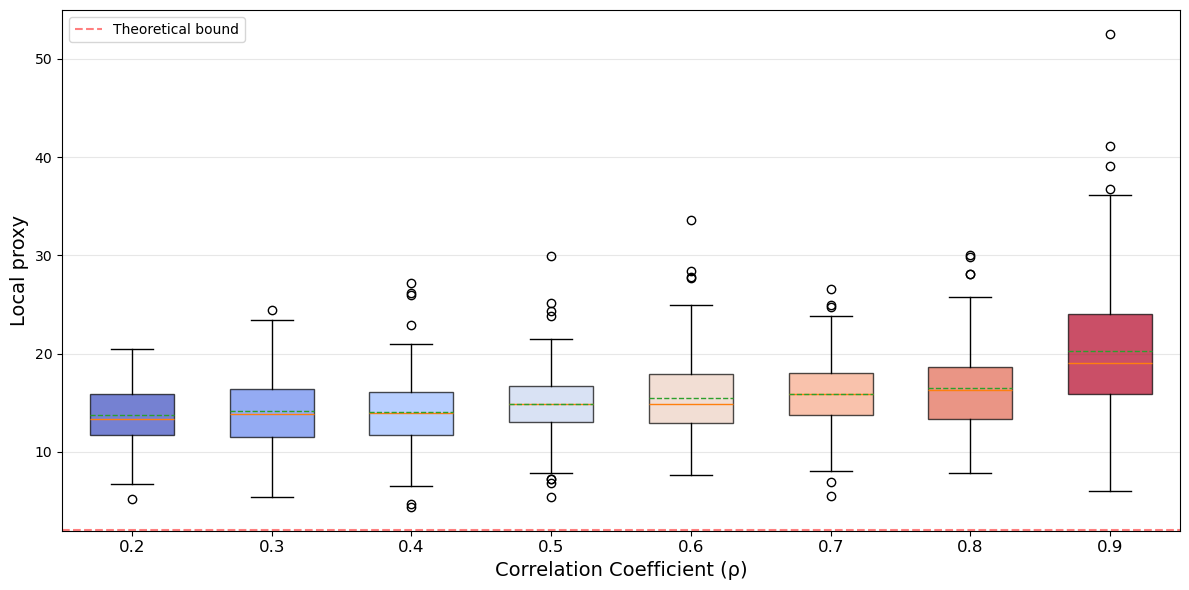

In [81]:
# =============================================================================
# CODE 1 (LOCAL PROXY / maxGCorr) — now uses the SAME 100 datasets per rho
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import scipy.linalg
from tqdm import tqdm

# -----------------------------
# DATASET CONTROL (FAIRNESS)
# -----------------------------
BASE_DATASET_SEED = 41  # <-- must match Code 2

def _seed_for_rho(rho: float, base_seed: int = BASE_DATASET_SEED) -> int:
    """
    Stable integer seed per rho (so both Code 1 and Code 2 generate identical X_rho^j).
    rho values like 0.2, 0.3, ..., 0.9 -> keys 200, 300, ..., 900.
    """
    key = int(round(rho * 1000))  
    return (base_seed + 100000 * key) % (2**32 - 1)

def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    """
    Generate X of shape (d, n) from N(0, Sigma(rho)) with equicorrelation rho.
    Uses ONLY the passed rng (so it is isolated from other randomness).
    """
    cov = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov, 1.0)
    X = rng.multivariate_normal(mean=np.zeros(d), cov=cov, size=n)
    return X.T  # (d, n)

def make_datasets_for_rho(n: int, d: int, rho: float, N: int, base_seed: int = BASE_DATASET_SEED):
    """
    Returns a list [X_rho^1, ..., X_rho^N], each of shape (d, n),
    deterministically determined by (base_seed, rho).
    """
    rng = np.random.default_rng(_seed_for_rho(rho, base_seed))
    return [generate_data_matrix_rng(rng, n, d, rho) for _ in range(N)]


# -----------------------------
# KL / MATRIX-NORMAL HELPERS
# -----------------------------
def kl_mvn(to, fr):
    m_to, S_to = to
    m_fr, S_fr = fr
    d = m_fr - m_to
    c, lower = scipy.linalg.cho_factor(S_fr)

    def solve(B):
        return scipy.linalg.cho_solve((c, lower), B)

    def logdet(S):
        return np.linalg.slogdet(S)[1]

    term1 = np.trace(solve(S_to))
    term2 = logdet(S_fr) - logdet(S_to)
    term3 = d.T @ solve(d)
    return (term1 + term2 + term3 - len(d)) / 2

def kl_mvn_stable(to, fr):
    m_to, S_to = to
    m_fr, S_fr = fr
    d = m_fr - m_to
    try:
        c, lower = scipy.linalg.cho_factor(S_fr)

        def solve(B):
            return scipy.linalg.cho_solve((c, lower), B)

        sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
        sign_to, logdet_to = np.linalg.slogdet(S_to)
        if sign_fr <= 0 or sign_to <= 0:
            return kl_mvn(to, fr)

        term1 = np.trace(solve(S_to))
        term2 = logdet_fr - logdet_to
        term3 = d.T @ solve(d)
        return (term1 + term2 + term3 - len(d)) / 2
    except np.linalg.LinAlgError:
        return kl_mvn(to, fr)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    KL between two matrix-normal distributions with row-covariance I_m:
        N(mu1, I_m ⊗ Sigma1)  vs  N(mu2, I_m ⊗ Sigma2)
    """
    m, _ = mu1.shape
    total_kl = 0.0
    for i in range(m):
        total_kl += kl_mvn_stable((mu1[i, :], Sigma1), (mu2[i, :], Sigma2))
    return total_kl

def symmetric_matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    kl1 = matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2)
    kl2 = matrix_kl_divergence(mu2, Sigma2, mu1, Sigma1)
    return 0.5 * (kl1 + kl2)


# -----------------------------
# MODEL / CAVI HELPERS
# -----------------------------
def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    return 1.0 / sigma_squared

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    max_iterations = 100000
    iteration = 0
    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            _, logdet_W = np.linalg.slogdet(sigma_W)
            _, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])
    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def generate_psd_perturbation(original_matrix, epsilon):
    eigenvalues, eigenvectors = np.linalg.eigh(original_matrix)
    perturbed_eigs = np.maximum(eigenvalues + epsilon, 1e-10)
    return eigenvectors @ np.diag(perturbed_eigs) @ eigenvectors.T

def compute_delta(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                  x, tau, d, n):
    Gamma_W = d * sigma_W + (mu_W.T @ mu_W)
    Gamma_z = n * sigma_z + (mu_z.T @ mu_z)
    Gamma_W_star = d * sigma_W_star + (mu_W_star.T @ mu_W_star)
    Gamma_z_star = n * sigma_z_star + (mu_z_star.T @ mu_z_star)

    mu_W_diff = mu_W - mu_W_star
    mu_z_diff = mu_z - mu_z_star

    term1 = tau * np.trace((mu_z_diff.T @ x.T) @ mu_W_diff)
    term2 = 0.5 * tau * np.trace((Gamma_W - Gamma_W_star) @ (Gamma_z - Gamma_z_star).T)
    return term1 - term2

def compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
                  x, tau, d, n):
    sym_kl_W = symmetric_matrix_kl_divergence(mu_W, sigma_W, mu_W_ref, sigma_W_ref)
    sym_kl_z = symmetric_matrix_kl_divergence(mu_z, sigma_z, mu_z_ref, sigma_z_ref)
    threshold = 1e-300

    if sym_kl_W > threshold and sym_kl_z > threshold:
        delta = compute_delta(
            mu_W, sigma_W, mu_z, sigma_z,
            mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
            x, tau, d, n
        )
        log_delta = np.log(max(abs(delta), threshold))
        log_gcorr = log_delta - 0.5 * (np.log(sym_kl_W) + np.log(sym_kl_z))
        gcorr = np.exp(log_gcorr)
        return gcorr, delta, sym_kl_W, sym_kl_z

    return None, None, sym_kl_W, sym_kl_z

def recurrence_iteration_with_tracking(mu_W, sigma_W, mu_z, sigma_z,
                                      Lambda, ELBOS, x, tau, d, n, k,
                                      mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                                      track_period=1):
    increment = 50
    max_iterations = 100000
    iteration = 0

    init_gcorr, _, _, _ = compute_gcorr(
        mu_W, sigma_W, mu_z, sigma_z,
        mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
        x, tau, d, n
    )
    max_gcorr = init_gcorr if init_gcorr is not None else 0.0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        # compute every iteration if track_period=1
        if track_period is not None and iteration % track_period == 0:
            gcorr, _, _, _ = compute_gcorr(
                mu_W, sigma_W, mu_z, sigma_z,
                mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                x, tau, d, n
            )
            if gcorr is not None and gcorr > max_gcorr:
                max_gcorr = gcorr

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            _, logdet_W = np.linalg.slogdet(sigma_W)
            _, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS, max_gcorr, init_gcorr


# -----------------------------
# WORKFLOW ON A FIXED DATASET x
# -----------------------------
def run_single_dataset_workflow_on_x(x, k, alpha, perturbation_scale=1e-15, m=50,
                                     track_period=1, rng_seed=123):
    """
    Same workflow, but takes x as input (so the dataset stream is controlled externally).
    All randomness for init/perturbations uses a LOCAL rng seeded by rng_seed, so it won't affect datasets.
    """
    d, n = x.shape
    tau = estimate_tau_ppca(x, k)
    Lambda = alpha * np.eye(k)

    rng = np.random.default_rng(rng_seed)

    # random init -> fixed point
    mu_W = rng.standard_normal((d, k))
    sigma_W = np.eye(k)
    mu_z = rng.standard_normal((n, k))
    sigma_z = np.eye(k)
    ELBOS = []

    mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS = recurrence_iteration(
        mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k
    )

    # m perturbations
    initial_gcorrs = []
    max_gcorrs = []
    for _ in range(m):
        mu_W_pert = mu_W_star + perturbation_scale * rng.standard_normal(mu_W_star.shape)
        mu_z_pert = mu_z_star + perturbation_scale * rng.standard_normal(mu_z_star.shape)
        sigma_W_pert = generate_psd_perturbation(sigma_W_star, perturbation_scale)
        sigma_z_pert = generate_psd_perturbation(sigma_z_star, perturbation_scale)

        ELBOS_new = []
        _, _, _, _, _, max_gcorr_i, init_gcorr_i = recurrence_iteration_with_tracking(
            mu_W_pert, sigma_W_pert, mu_z_pert, sigma_z_pert,
            Lambda, ELBOS_new, x, tau, d, n, k,
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
            track_period=track_period
        )

        initial_gcorrs.append(init_gcorr_i if init_gcorr_i is not None else 0.0)
        max_gcorrs.append(max_gcorr_i if max_gcorr_i is not None else 0.0)

    best_idx = int(np.argmax(max_gcorrs)) if len(max_gcorrs) else 0
    return {
        "max_gcorr": max_gcorrs[best_idx] if max_gcorrs else None,
        "initial_gcorr": initial_gcorrs[best_idx] if initial_gcorrs else None,
        "m": m
    }


# =============================================================================
# ANALYSIS ACROSS MULTIPLE RHO VALUES (LOCAL PROXY)
# =============================================================================
if __name__ == "__main__":
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    all_max_gcorrs_by_rho = []

    # Parameters
    d = 3
    n = 20
    k = 2
    alpha = 1.0
    N_per_rho = 100
    perturbation_scale = 1e-7
    m = 100  # number of perturbations
    track_period = 1  # compute gcorr every iteration

    print("Running experiments across multiple rho values...")

    for rho in tqdm(rho_values, desc="Varying rho"):
        # FIXED: deterministic datasets for this rho (shared with Code 2)
        datasets = make_datasets_for_rho(n, d, rho, N_per_rho, base_seed=BASE_DATASET_SEED)

        max_gcorrs_rho = []
        for j, x in enumerate(datasets):
            # local rng seed per dataset (does NOT affect dataset generation)
            result = run_single_dataset_workflow_on_x(
                x, k, alpha,
                perturbation_scale=perturbation_scale,
                m=m,
                track_period=track_period,
                rng_seed=10_000 + j  # any deterministic choice is fine
            )
            max_gcorrs_rho.append(result["max_gcorr"])
        all_max_gcorrs_by_rho.append(max_gcorrs_rho)

    # Plot box plot
    plt.figure(figsize=(12, 6))
    box = plt.boxplot(all_max_gcorrs_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=12)
    plt.xlabel("Correlation Coefficient (ρ)", fontsize=14)
    plt.ylabel("Local proxy", fontsize=14)
    plt.grid(True, alpha=0.3, axis="y")

    plt.axhline(y=2, color="red", linestyle="--", alpha=0.5, label="Theoretical bound")
    plt.legend()

    plt.tight_layout()
    plt.savefig("maxGCorrboxplot_shared_datasets_final1.pdf", format="pdf", bbox_inches="tight")
    plt.show()


In [ ]:
# =============================================================================
# CELL 1: COMPUTE (LOCAL PROXY / maxGCorr) + SAVE RAW RESULTS
# =============================================================================
import os
import numpy as np
import pandas as pd
from scipy.linalg import eigh
import scipy.linalg
from tqdm import tqdm

# -----------------------------
# DATASET CONTROL 
# -----------------------------
BASE_DATASET_SEED = 41  # <-- must match Code 2

def _seed_for_rho(rho: float, base_seed: int = BASE_DATASET_SEED) -> int:
    """
    Stable integer seed per rho (so both Code 1 and Code 2 generate identical X_rho^j).
    rho values like 0.2, 0.3, ..., 0.9 -> keys 200, 300, ..., 900.
    """
    key = int(round(rho * 1000))  
    return (base_seed + 100000 * key) % (2**32 - 1)

def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    """
    Generate X of shape (d, n) from N(0, Sigma(rho)) with equicorrelation rho.
    Uses ONLY the passed rng (so it is isolated from other randomness).
    """
    cov = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov, 1.0)
    X = rng.multivariate_normal(mean=np.zeros(d), cov=cov, size=n)
    return X.T  # (d, n)

def make_datasets_for_rho(n: int, d: int, rho: float, N: int, base_seed: int = BASE_DATASET_SEED):
    """
    Returns a list [X_rho^1, ..., X_rho^N], each of shape (d, n),
    deterministically determined by (base_seed, rho).
    """
    rng = np.random.default_rng(_seed_for_rho(rho, base_seed))
    return [generate_data_matrix_rng(rng, n, d, rho) for _ in range(N)]


# -----------------------------
# KL / MATRIX-NORMAL HELPERS
# -----------------------------
def kl_mvn(to, fr):
    m_to, S_to = to
    m_fr, S_fr = fr
    d = m_fr - m_to
    c, lower = scipy.linalg.cho_factor(S_fr)

    def solve(B):
        return scipy.linalg.cho_solve((c, lower), B)

    def logdet(S):
        return np.linalg.slogdet(S)[1]

    term1 = np.trace(solve(S_to))
    term2 = logdet(S_fr) - logdet(S_to)
    term3 = d.T @ solve(d)
    return (term1 + term2 + term3 - len(d)) / 2

def kl_mvn_stable(to, fr):
    m_to, S_to = to
    m_fr, S_fr = fr
    d = m_fr - m_to
    try:
        c, lower = scipy.linalg.cho_factor(S_fr)

        def solve(B):
            return scipy.linalg.cho_solve((c, lower), B)

        sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
        sign_to, logdet_to = np.linalg.slogdet(S_to)
        if sign_fr <= 0 or sign_to <= 0:
            return kl_mvn(to, fr)

        term1 = np.trace(solve(S_to))
        term2 = logdet_fr - logdet_to
        term3 = d.T @ solve(d)
        return (term1 + term2 + term3 - len(d)) / 2
    except np.linalg.LinAlgError:
        return kl_mvn(to, fr)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    KL between two matrix-normal distributions with row-covariance I_m:
        N(mu1, I_m ⊗ Sigma1)  vs  N(mu2, I_m ⊗ Sigma2)
    """
    m, _ = mu1.shape
    total_kl = 0.0
    for i in range(m):
        total_kl += kl_mvn_stable((mu1[i, :], Sigma1), (mu2[i, :], Sigma2))
    return total_kl

def symmetric_matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    kl1 = matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2)
    kl2 = matrix_kl_divergence(mu2, Sigma2, mu1, Sigma1)
    return 0.5 * (kl1 + kl2)


# -----------------------------
# MODEL / CAVI HELPERS
# -----------------------------
def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    return 1.0 / sigma_squared

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    max_iterations = 100000
    iteration = 0
    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            _, logdet_W = np.linalg.slogdet(sigma_W)
            _, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])
    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def generate_psd_perturbation(original_matrix, epsilon):
    eigenvalues, eigenvectors = np.linalg.eigh(original_matrix)
    perturbed_eigs = np.maximum(eigenvalues + epsilon, 1e-10)
    return eigenvectors @ np.diag(perturbed_eigs) @ eigenvectors.T

def compute_delta(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                  x, tau, d, n):
    Gamma_W = d * sigma_W + (mu_W.T @ mu_W)
    Gamma_z = n * sigma_z + (mu_z.T @ mu_z)
    Gamma_W_star = d * sigma_W_star + (mu_W_star.T @ mu_W_star)
    Gamma_z_star = n * sigma_z_star + (mu_z_star.T @ mu_z_star)

    mu_W_diff = mu_W - mu_W_star
    mu_z_diff = mu_z - mu_z_star

    term1 = tau * np.trace((mu_z_diff.T @ x.T) @ mu_W_diff)
    term2 = 0.5 * tau * np.trace((Gamma_W - Gamma_W_star) @ (Gamma_z - Gamma_z_star).T)
    return term1 - term2

def compute_gcorr(mu_W, sigma_W, mu_z, sigma_z,
                  mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
                  x, tau, d, n):
    sym_kl_W = symmetric_matrix_kl_divergence(mu_W, sigma_W, mu_W_ref, sigma_W_ref)
    sym_kl_z = symmetric_matrix_kl_divergence(mu_z, sigma_z, mu_z_ref, sigma_z_ref)
    threshold = 1e-300

    if sym_kl_W > threshold and sym_kl_z > threshold:
        delta = compute_delta(
            mu_W, sigma_W, mu_z, sigma_z,
            mu_W_ref, sigma_W_ref, mu_z_ref, sigma_z_ref,
            x, tau, d, n
        )
        log_delta = np.log(max(abs(delta), threshold))
        log_gcorr = log_delta - 0.5 * (np.log(sym_kl_W) + np.log(sym_kl_z))
        gcorr = np.exp(log_gcorr)
        return gcorr, delta, sym_kl_W, sym_kl_z

    return None, None, sym_kl_W, sym_kl_z

def recurrence_iteration_with_tracking(mu_W, sigma_W, mu_z, sigma_z,
                                      Lambda, ELBOS, x, tau, d, n, k,
                                      mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                                      track_period=1):
    increment = 50
    max_iterations = 100000
    iteration = 0

    init_gcorr, _, _, _ = compute_gcorr(
        mu_W, sigma_W, mu_z, sigma_z,
        mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
        x, tau, d, n
    )
    max_gcorr = init_gcorr if init_gcorr is not None else 0.0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        # compute every iteration if track_period=1
        if track_period is not None and iteration % track_period == 0:
            gcorr, _, _, _ = compute_gcorr(
                mu_W, sigma_W, mu_z, sigma_z,
                mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
                x, tau, d, n
            )
            if gcorr is not None and gcorr > max_gcorr:
                max_gcorr = gcorr

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            _, logdet_W = np.linalg.slogdet(sigma_W)
            _, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - (tau / 2) * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * k * logdet_W
                + 0.5 * k * logdet_z
            )
            ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS, max_gcorr, init_gcorr


# -----------------------------
# WORKFLOW ON A FIXED DATASET x
# -----------------------------
def run_single_dataset_workflow_on_x(x, k, alpha, perturbation_scale=1e-15, m=50,
                                     track_period=1, rng_seed=123):
    """
    Same as workflow, but takes x as input (so the dataset stream is controlled externally).
    All randomness for init/perturbations uses a LOCAL rng seeded by rng_seed, so it won't affect datasets.
    """
    d, n = x.shape
    tau = estimate_tau_ppca(x, k)
    Lambda = alpha * np.eye(k)

    rng = np.random.default_rng(rng_seed)

    # random init -> fixed point
    mu_W = rng.standard_normal((d, k))
    sigma_W = np.eye(k)
    mu_z = rng.standard_normal((n, k))
    sigma_z = np.eye(k)
    ELBOS = []

    mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, ELBOS = recurrence_iteration(
        mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k
    )

    # m perturbations
    initial_gcorrs = []
    max_gcorrs = []
    for _ in range(m):
        mu_W_pert = mu_W_star + perturbation_scale * rng.standard_normal(mu_W_star.shape)
        mu_z_pert = mu_z_star + perturbation_scale * rng.standard_normal(mu_z_star.shape)
        sigma_W_pert = generate_psd_perturbation(sigma_W_star, perturbation_scale)
        sigma_z_pert = generate_psd_perturbation(sigma_z_star, perturbation_scale)

        ELBOS_new = []
        _, _, _, _, _, max_gcorr_i, init_gcorr_i = recurrence_iteration_with_tracking(
            mu_W_pert, sigma_W_pert, mu_z_pert, sigma_z_pert,
            Lambda, ELBOS_new, x, tau, d, n, k,
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star,
            track_period=track_period
        )

        initial_gcorrs.append(init_gcorr_i if init_gcorr_i is not None else 0.0)
        max_gcorrs.append(max_gcorr_i if max_gcorr_i is not None else 0.0)

    best_idx = int(np.argmax(max_gcorrs)) if len(max_gcorrs) else 0
    return {
        "max_gcorr": max_gcorrs[best_idx] if max_gcorrs else None,
        "initial_gcorr": initial_gcorrs[best_idx] if initial_gcorrs else None,
        "m": m
    }


# =============================================================================
# ANALYSIS ACROSS MULTIPLE RHO VALUES (COMPUTE + SAVE)
# =============================================================================
# ---- output paths
OUT_CSV = "maxGCorr_raw_shared_datasets.csv"
OUT_NPZ = "maxGCorr_raw_shared_datasets.npz"

rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Parameters
d = 3
n = 20
k = 2
alpha = 1.0
N_per_rho = 100
perturbation_scale = 1e-7
m = 100  # number of perturbations
track_period = 1  # compute gcorr every iteration

print("Running experiments across multiple rho values...")

rows = []
all_max_gcorrs_by_rho = []  # still keep this structure in memory

for rho in tqdm(rho_values, desc="Varying rho"):
    # deterministic datasets for this rho (shared with Code 2)
    datasets = make_datasets_for_rho(n, d, rho, N_per_rho, base_seed=BASE_DATASET_SEED)

    max_gcorrs_rho = []
    for j, x in enumerate(datasets):
        result = run_single_dataset_workflow_on_x(
            x, k, alpha,
            perturbation_scale=perturbation_scale,
            m=m,
            track_period=track_period,
            rng_seed=10_000 + j
        )

        max_g = float(result["max_gcorr"]) if result["max_gcorr"] is not None else np.nan
        init_g = float(result["initial_gcorr"]) if result["initial_gcorr"] is not None else np.nan

        max_gcorrs_rho.append(max_g)

        # raw row (store BOTH raw + corrected proxy)
        rows.append({
            "rho": rho,
            "dataset_idx": j,
            "max_gcorr_raw": max_g,
            "initial_gcorr_raw": init_g,
            "local_proxy_corrected": 0.5 * max_g,  
            "base_dataset_seed": BASE_DATASET_SEED,
            "rng_seed_init_perturb": 10_000 + j,
            "d": d, "n": n, "k": k, "alpha": alpha,
            "N_per_rho": N_per_rho,
            "perturbation_scale": perturbation_scale,
            "m": m,
            "track_period": track_period,
        })

    all_max_gcorrs_by_rho.append(max_gcorrs_rho)

# Save CSV 
df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved raw results to: {OUT_CSV}  (rows={len(df)})")

# Optional: also save a compact NPZ for very fast reload of the main arrays
np.savez(
    OUT_NPZ,
    rho_values=np.array(rho_values, dtype=float),
    all_max_gcorrs_by_rho=np.array(all_max_gcorrs_by_rho, dtype=float),
    base_dataset_seed=np.array([BASE_DATASET_SEED], dtype=np.int64),
    d=np.array([d]), n=np.array([n]), k=np.array([k]), alpha=np.array([alpha]),
    N_per_rho=np.array([N_per_rho]), perturbation_scale=np.array([perturbation_scale]),
    m=np.array([m]), track_period=np.array([track_period]),
)
print(f"Saved fast-reload arrays to: {OUT_NPZ}")


Running experiments across multiple rho values...


Varying rho:  88%|████████████████████████▌   | 7/8 [5:50:53<46:17, 2777.00s/it]

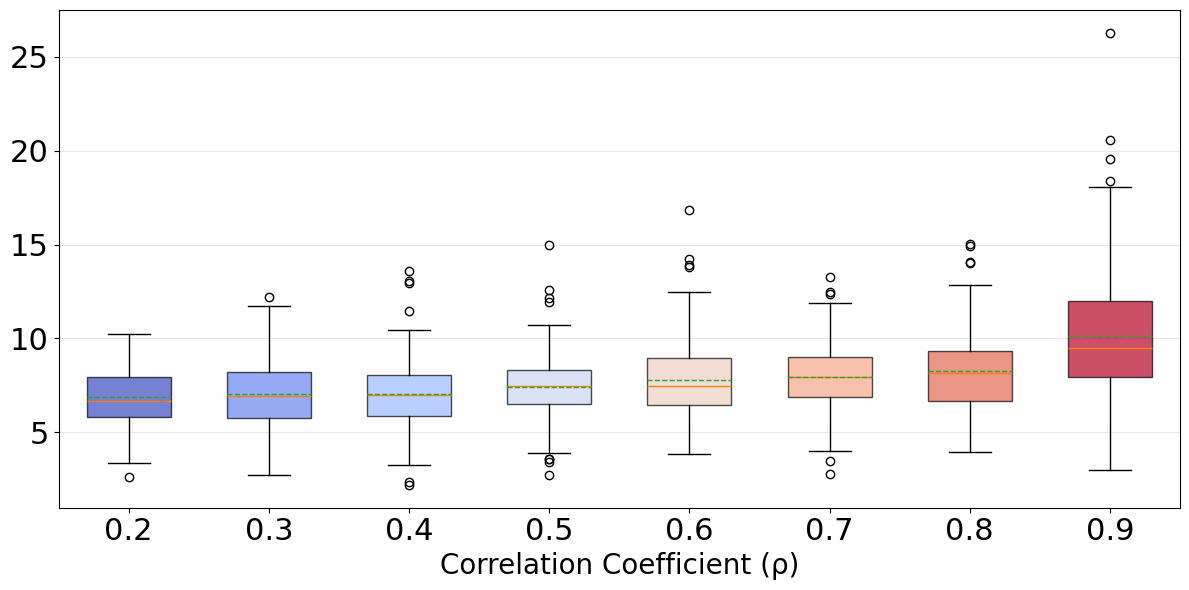

In [17]:
# =============================================================================
# CELL 2: LOAD RESULTS + BOXPLOT (LOCAL PROXY = 0.5 * max_gcorr)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "maxGCorr_raw_shared_datasets.csv"

df = pd.read_csv(IN_CSV)

rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Build the boxplot data in the same shape as before: list over rho of 100 values
all_proxy_by_rho = []
for rho in rho_values:
    vals = df.loc[df["rho"] == rho, "local_proxy_corrected"].to_numpy(dtype=float)
    all_proxy_by_rho.append(vals)

plt.figure(figsize=(12, 6))
box = plt.boxplot(all_proxy_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
plt.yticks(fontsize=22) 
plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)

plt.grid(True, alpha=0.3, axis="y")

#plt.axhline(y=2, color="red", linestyle="--", alpha=0.5, label="Theoretical bound")
#plt.legend()

plt.tight_layout()
plt.savefig("maxGCorrboxplot_shared_datasets_corrected1.pdf", format="pdf", bbox_inches="tight")
plt.show()


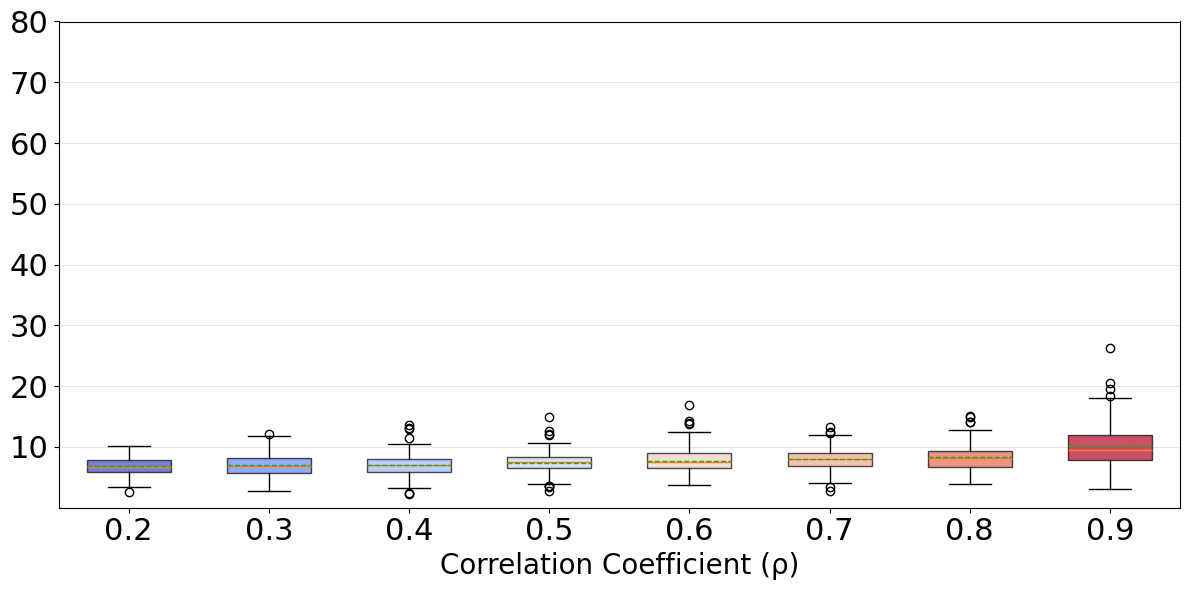

In [25]:
# =============================================================================
# CELL 2: LOAD RESULTS + BOXPLOT (LOCAL PROXY = 0.5 * max_gcorr)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "maxGCorr_raw_shared_datasets.csv"
df = pd.read_csv(IN_CSV)

rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


all_proxy_by_rho = []
for rho in rho_values:
    vals = df.loc[df["rho"] == rho, "local_proxy_corrected"].to_numpy(dtype=float)
    all_proxy_by_rho.append(vals)

plt.figure(figsize=(12, 6))
box = plt.boxplot(all_proxy_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
plt.yticks(ticks=np.arange(10, 81, 10), fontsize=22)  # <-- ticks every 10
plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)

plt.ylim(0, 80)

plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
#plt.savefig("maxGCorrboxplot_shared_datasets_corrected4.pdf", format="pdf", bbox_inches="tight")
plt.show()


Computing m_j (= M_i) distributions across rho values...


rho loop:  12%|████▍                              | 1/8 [00:00<00:01,  3.86it/s]

rho=0.2: successful 100/100
rho=0.3: successful 100/100


rho loop:  38%|█████████████▏                     | 3/8 [00:00<00:01,  4.36it/s]

rho=0.4: successful 100/100


...

rho=0.7: successful 100/100


rho loop:  88%|██████████████████████████████▋    | 7/8 [00:02<00:00,  2.67it/s]

rho=0.8: successful 100/100


rho loop: 100%|███████████████████████████████████| 8/8 [00:03<00:00,  2.62it/s]

rho=0.9: successful 100/100

Wrote shared scale to: shared_ylims_code1min_code2max.json
Shared y-limits: [2.18925, 79.2724] with 9 equispaced ticks.


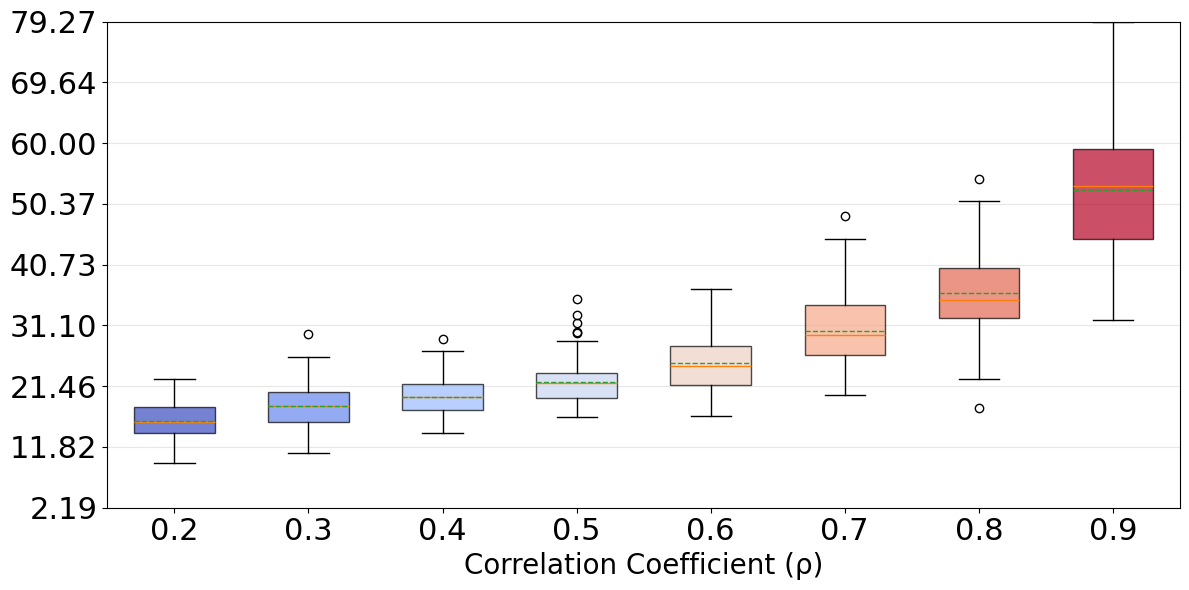


Summary Statistics by ρ value:
------------------------------------------------------------------------
ρ      Nsucc  Mean         Median       Std          Min          Max         
------------------------------------------------------------------------
0.2    100    16.0136      15.7425      2.8360       9.2637       22.6563     
0.3    100    18.2413      18.2647      3.1776       10.8457      29.7941     
0.4    100    19.7245      19.7406      2.9237       14.0337      29.0092     
0.5    100    22.0942      21.9998      3.5674       16.5517      35.2314     
0.6    100    25.1301      24.6740      4.4678       16.6941      36.8026     
0.7    100    30.2781      29.5266      5.4649       20.0262      48.4936     
0.8    100    36.2522      35.0815      6.5065       17.9438      54.3510     
0.9    100    52.6121      53.1548      10.5756      31.9399      79.2724     


In [41]:
# =============================================================================
# CODE 2 (Upper-bound proxy via M_i) — CLEAN + writes shared y-scale
# Shared scale = [min(Code1 local_proxy_corrected), max(Code2 m_j)]
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from scipy.linalg import eigh
from tqdm import tqdm

# -----------------------------------------------------------------------------
# Shared scale config
# -----------------------------------------------------------------------------
IN_CSV = "maxGCorr_raw_shared_datasets.csv"   # contains local_proxy_corrected from Code 1
YLIM_JSON = "shared_ylims_code1min_code2max.json"
N_TICKS = 9  # equispaced ticks

def _finite_min(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("No finite values found for min.")
    return float(np.min(x))

def _finite_max(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("No finite values found for max.")
    return float(np.max(x))

# -----------------------------------------------------------------------------
#  dataset control
# -----------------------------------------------------------------------------
BASE_DATASET_SEED = 41

def _seed_for_rho(rho: float, base_seed: int = BASE_DATASET_SEED) -> int:
    key = int(round(rho * 1000))
    return (base_seed + 100000 * key) % (2**32 - 1)

def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    cov_matrix = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = rng.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T  # (d, n)

def make_datasets_for_rho(n: int, d: int, rho: float, N: int, base_seed: int = BASE_DATASET_SEED):
    rng = np.random.default_rng(_seed_for_rho(rho, base_seed))
    return [generate_data_matrix_rng(rng, n, d, rho) for _ in range(N)]

# -----------------------------------------------------------------------------
# PPCA tau estimate
# -----------------------------------------------------------------------------
def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-8
    return 1.0 / sigma_squared

# -----------------------------------------------------------------------------
# CAVI recurrence 
# -----------------------------------------------------------------------------
def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    max_iterations = 100000
    iteration = 0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        B = (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) @ (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)
        C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
        D = np.trace(mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)

        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)
        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")

        ELBO = (
            tau * np.trace((mu_W @ mu_z.T) @ x.T)
            - (tau / 2) * np.trace(B)
            - 0.5 * C
            - 0.5 * D
            + 0.5 * d * logdet_W
            + 0.5 * n * logdet_z
        )
        ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

# -----------------------------------------------------------------------------
# M_i computation 
# -----------------------------------------------------------------------------
def compute_M_i(x, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau, n, d):
    gamma0 = 0.25 * (1 + math.e**(-1))

    norm_sigma_W = np.linalg.norm(sigma_W_star, ord="fro")
    norm_sigma_z = np.linalg.norm(sigma_z_star, ord="fro")
    norm_mu_W = np.linalg.norm(mu_W_star, ord="fro")
    norm_mu_z = np.linalg.norm(mu_z_star, ord="fro")
    norm_x = np.linalg.norm(x, ord="fro")

    key_term_star = norm_x + 2 * norm_mu_W * norm_mu_z

    term1 = ((norm_sigma_W * norm_sigma_z) ** 0.5 * key_term_star) / gamma0
    term2 = 2 * math.e * (norm_sigma_W * norm_sigma_z) * math.sqrt(n * d)
    term3 = (norm_sigma_W * (norm_sigma_z ** 0.5) * math.sqrt(2 * d * math.e) * norm_mu_z) / (gamma0**0.5)
    term4 = ((norm_sigma_W ** 0.5) * norm_sigma_z * math.sqrt(2 * n * math.e) * norm_mu_W) / (gamma0**0.5)

    return tau * max(term1, term2, term3, term4)

# -----------------------------------------------------------------------------
# For one fixed rho: compute m_i for j=1..N datasets
# -----------------------------------------------------------------------------
def compute_m_values_for_rho(n, d, k, rho, N_per_rho=100, base_seed=BASE_DATASET_SEED):
    datasets = make_datasets_for_rho(n, d, rho, N_per_rho, base_seed=base_seed)

    mu_W0 = np.full((d, k), 0.1)
    sigma_W0 = np.eye(k)
    mu_z0 = np.full((n, k), 0.1)
    sigma_z0 = np.eye(k)

    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))
    Lambda = np.diag(diagonal_elements[:k])

    m_values = []

    for x_j in datasets:
        tau_j = estimate_tau_ppca(x_j, k)
        ELBOS = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, _ = recurrence_iteration(
                mu_W0.copy(), sigma_W0.copy(), mu_z0.copy(), sigma_z0.copy(),
                Lambda, ELBOS, x_j, tau_j, d, n, k
            )
            m_j = compute_M_i(x_j, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_j, n, d)
            if np.isfinite(m_j):
                m_values.append(float(m_j))
        except Exception:
            continue

    return m_values


def compare_rho_values():
    # ---- get Code 1 minimum from saved CSV ----
    df = pd.read_csv(IN_CSV)
    y_min = _finite_min(df["local_proxy_corrected"].to_numpy(dtype=float))

    # ---- run Code 2 computation ----
    n, d, k = 20, 3, 2
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    N_per_rho = 100

    all_m_values = []

    print("Computing m_j (= M_i) distributions across rho values...")
    for rho in tqdm(rho_values, desc="rho loop"):
        m_vals = compute_m_values_for_rho(
            n, d, k, rho,
            N_per_rho=N_per_rho,
            base_seed=BASE_DATASET_SEED
        )
        all_m_values.append(m_vals)
        print(f"rho={rho}: successful {len(m_vals)}/{N_per_rho}")

    flat_m = np.array([v for sub in all_m_values for v in sub], dtype=float)
    y_max = _finite_max(flat_m)

    # ---- write shared scale for Code 1 ----
    payload = {"y_min": y_min, "y_max": y_max, "n_ticks": N_TICKS}
    with open(YLIM_JSON, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"\nWrote shared scale to: {YLIM_JSON}")
    print(f"Shared y-limits: [{y_min:.6g}, {y_max:.6g}] with {N_TICKS} equispaced ticks.")

    # ---- plotting (using shared scale) ----
    yticks = np.linspace(y_min, y_max, N_TICKS)

    plt.figure(figsize=(12, 6))
    box_plot = plt.boxplot(all_m_values, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box_plot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
    plt.yticks(ticks=yticks, fontsize=22)
    plt.ylim(y_min, y_max)

    plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)
    plt.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("Upperbound_mj_shared_seed_final5.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Summary stats
    print("\nSummary Statistics by ρ value:")
    print("-" * 72)
    print(f"{'ρ':<6} {'Nsucc':<6} {'Mean':<12} {'Median':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-" * 72)
    for rho, m_vals in zip(rho_values, all_m_values):
        if len(m_vals) == 0:
            print(f"{rho:<6} {0:<6} {'-':<12} {'-':<12} {'-':<12} {'-':<12} {'-':<12}")
        else:
            mv = np.array(m_vals, dtype=float)
            print(
                f"{rho:<6} {len(m_vals):<6} "
                f"{np.mean(mv):<12.4f} {np.median(mv):<12.4f} "
                f"{np.std(mv):<12.4f} {np.min(mv):<12.4f} {np.max(mv):<12.4f}"
            )

    return all_m_values, rho_values

# -----------------------------------------------------------------------------
# Run
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    compare_rho_values()


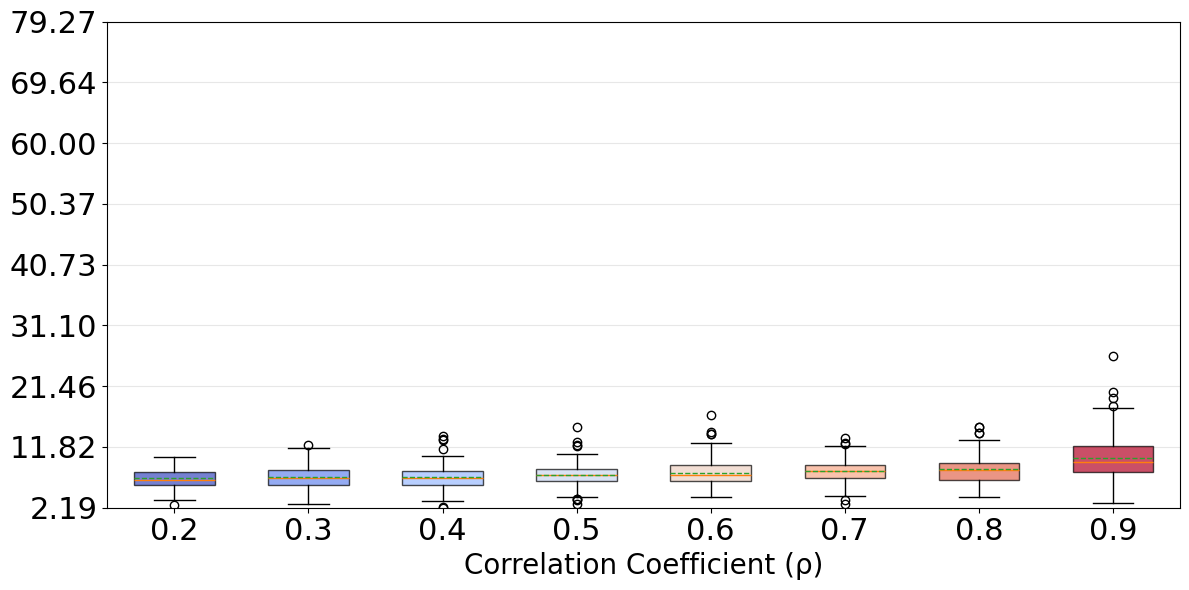

In [43]:
# =============================================================================
# CODE 1: LOAD RESULTS + BOXPLOT 
# Uses shared y-scale written by Code 2: [min(Code1), max(Code2)]
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

IN_CSV = "maxGCorr_raw_shared_datasets.csv"
YLIM_JSON = "shared_ylims_code1min_code2max.json"  # written by Code 2
DEFAULT_N_TICKS = 9

df = pd.read_csv(IN_CSV)

rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Build the boxplot data: list over rho of values
all_proxy_by_rho = []
for rho in rho_values:
    vals = df.loc[df["rho"] == rho, "local_proxy_corrected"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    all_proxy_by_rho.append(vals)

# --- shared scale ---
if os.path.exists(YLIM_JSON):
    with open(YLIM_JSON, "r") as f:
        payload = json.load(f)
    y_min = float(payload["y_min"])
    y_max = float(payload["y_max"])
    n_ticks = int(payload.get("n_ticks", DEFAULT_N_TICKS))
else:
    # fallback 
    flat = np.concatenate([v for v in all_proxy_by_rho if len(v) > 0]).astype(float)
    flat = flat[np.isfinite(flat)]
    y_min, y_max = float(np.min(flat)), float(np.max(flat))
    n_ticks = DEFAULT_N_TICKS

yticks = np.linspace(y_min, y_max, n_ticks)

plt.figure(figsize=(12, 6))
box = plt.boxplot(all_proxy_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
plt.yticks(ticks=yticks, fontsize=22)
plt.ylim(y_min, y_max)

plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)
plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("maxGCorrboxplot_shared_datasets_corrected_SHARED_SCALE_final5.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [39]:
# =============================================================================
# SUMMARY TABLE (for Code 1 proxies) — same format as Code 2's summary table
# Assumes:
#   - rho_values (list)
#   - all_proxy_by_rho (list of arrays/lists, aligned with rho_values)
# =============================================================================
import numpy as np

print("\nSummary Statistics (local_proxy_corrected) by ρ value:")
print("-" * 72)
print(f"{'ρ':<6} {'N':<6} {'Mean':<12} {'Median':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 72)

for rho, vals in zip(rho_values, all_proxy_by_rho):
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        print(f"{rho:<6} {0:<6} {'-':<12} {'-':<12} {'-':<12} {'-':<12} {'-':<12}")
    else:
        print(
            f"{rho:<6} {v.size:<6} "
            f"{np.mean(v):<12.4f} {np.median(v):<12.4f} "
            f"{np.std(v):<12.4f} {np.min(v):<12.4f} {np.max(v):<12.4f}"
        )



Summary Statistics (local_proxy_corrected) by ρ value:
------------------------------------------------------------------------
ρ      N      Mean         Median       Std          Min          Max         
------------------------------------------------------------------------
0.2    100    6.8861       6.6572       1.5301       2.6133       10.2240     
0.3    100    7.0541       6.9394       1.8255       2.7025       12.2060     
0.4    100    7.0487       6.9746       1.9881       2.1893       13.5793     
0.5    100    7.4258       7.4510       2.0117       2.7141       14.9648     
0.6    100    7.7655       7.4461       2.2377       3.8196       16.8241     
0.7    100    7.9539       7.9499       1.9755       2.7721       13.2938     
0.8    100    8.2665       8.1634       2.2619       3.9456       15.0116     
0.9    100    10.1341      9.5027       3.5090       3.0108       26.2844     


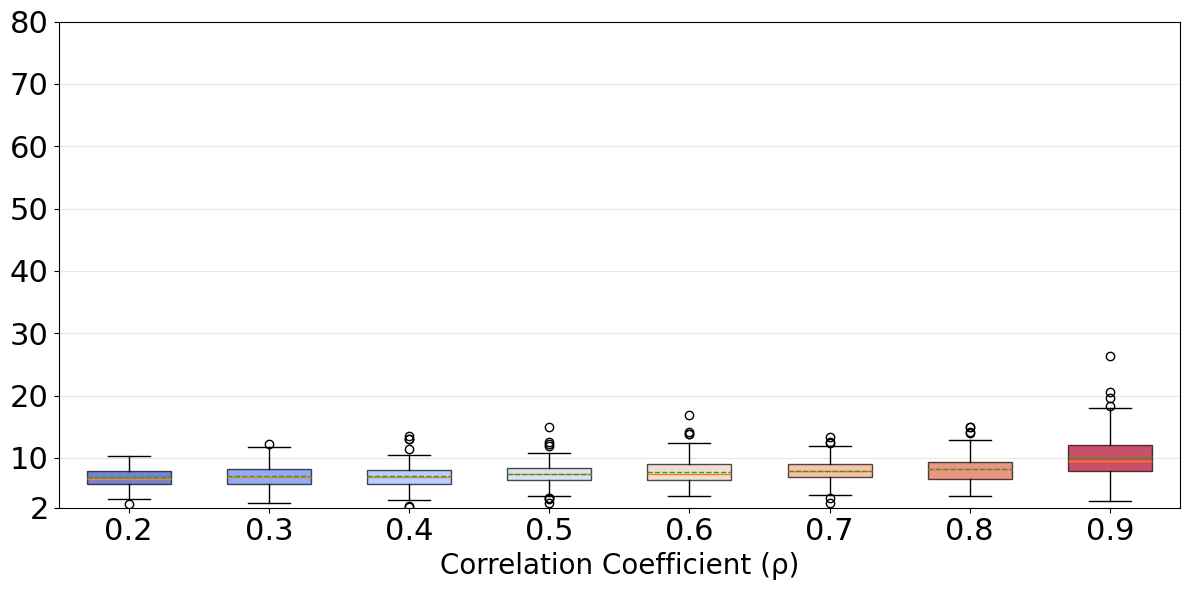

In [53]:
# =============================================================================
# CODE 1: LOAD RESULTS + BOXPLOT
# y-axis: fixed to [2,80] with nice ticks
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "maxGCorr_raw_shared_datasets.csv"
df = pd.read_csv(IN_CSV)

rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Build the boxplot data
all_proxy_by_rho = []
for rho in rho_values:
    vals = df.loc[df["rho"] == rho, "local_proxy_corrected"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    all_proxy_by_rho.append(vals)

# Fixed shared scale
Y_MIN, Y_MAX = 2, 80
Y_TICKS = [2, 10, 20, 30, 40, 50, 60, 70, 80]

plt.figure(figsize=(12, 6))
box = plt.boxplot(all_proxy_by_rho, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
plt.yticks(ticks=Y_TICKS, fontsize=22)
plt.ylim(Y_MIN, Y_MAX)

plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)
plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("maxGCorrboxplot_shared_datasets_final6.pdf", format="pdf", bbox_inches="tight")
plt.show()


Computing m_j (= M_i) distributions across rho values...


rho loop:  12%|████▍                              | 1/8 [00:00<00:02,  2.90it/s]

rho=0.2: successful 100/100


rho loop:  38%|█████████████▏                     | 3/8 [00:01<00:01,  2.94it/s]

rho=0.3: successful 100/100
rho=0.4: successful 100/100


...

rho loop:  75%|██████████████████████████▎        | 6/8 [00:02<00:00,  2.13it/s]

rho=0.6: successful 100/100
rho=0.7: successful 100/100


rho loop: 100%|███████████████████████████████████| 8/8 [00:04<00:00,  1.21it/s]

rho=0.8: successful 100/100
rho=0.9: successful 100/100


rho loop: 100%|███████████████████████████████████| 8/8 [00:04<00:00,  1.73it/s]


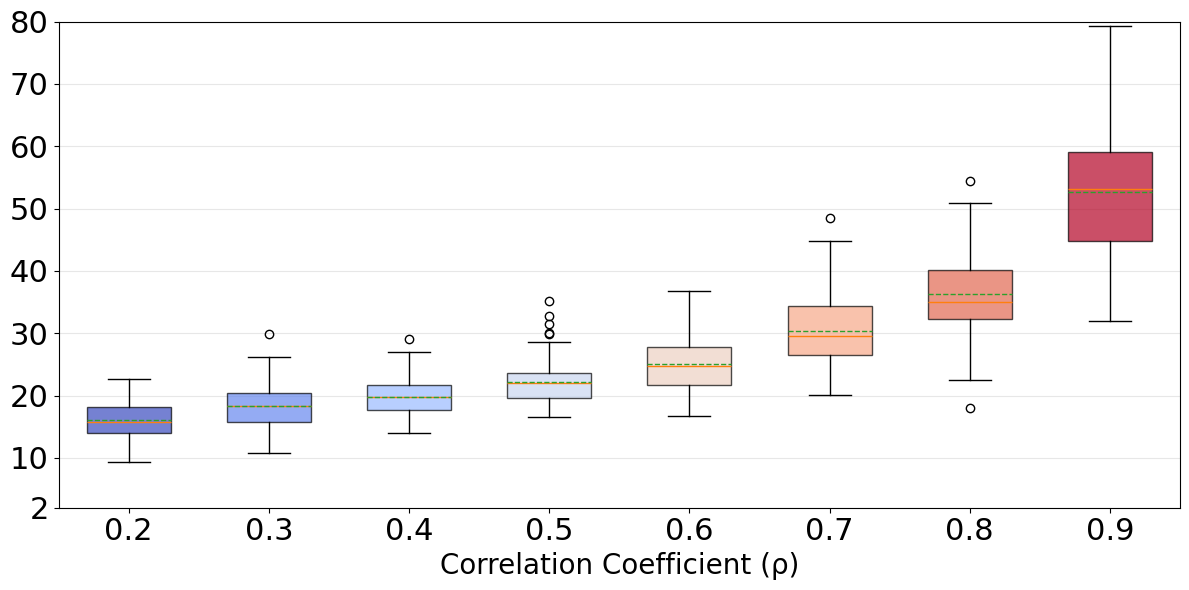


Summary Statistics by ρ value:
------------------------------------------------------------------------
ρ      Nsucc  Mean         Median       Std          Min          Max         
------------------------------------------------------------------------
0.2    100    16.0136      15.7425      2.8360       9.2637       22.6563     
0.3    100    18.2413      18.2647      3.1776       10.8457      29.7941     
0.4    100    19.7245      19.7406      2.9237       14.0337      29.0092     
0.5    100    22.0942      21.9998      3.5674       16.5517      35.2314     
0.6    100    25.1301      24.6740      4.4678       16.6941      36.8026     
0.7    100    30.2781      29.5266      5.4649       20.0262      48.4936     
0.8    100    36.2522      35.0815      6.5065       17.9438      54.3510     
0.9    100    52.6121      53.1548      10.5756      31.9399      79.2724     


In [51]:
# =============================================================================
# CODE 2 (Upper-bound proxy via M_i) — CLEAN + fixed shared y-scale
# y-axis: fixed to [2,80] 
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import eigh
from tqdm import tqdm

# Fixed shared scale (MUST match Code 1)
Y_MIN, Y_MAX = 2, 80
Y_TICKS = [2, 10, 20, 30, 40, 50, 60, 70, 80]

# -----------------------------------------------------------------------------
# dataset control
# -----------------------------------------------------------------------------
BASE_DATASET_SEED = 41

def _seed_for_rho(rho: float, base_seed: int = BASE_DATASET_SEED) -> int:
    key = int(round(rho * 1000))
    return (base_seed + 100000 * key) % (2**32 - 1)

def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    cov_matrix = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov_matrix, 1.0)
    data_points = rng.multivariate_normal(mean=np.zeros(d), cov=cov_matrix, size=n)
    return data_points.T  # (d, n)

def make_datasets_for_rho(n: int, d: int, rho: float, N: int, base_seed: int = BASE_DATASET_SEED):
    rng = np.random.default_rng(_seed_for_rho(rho, base_seed))
    return [generate_data_matrix_rng(rng, n, d, rho) for _ in range(N)]

def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    sigma_squared = np.mean(eigenvalues[k:]) if (d - k > 0) else 1e-8
    return 1.0 / sigma_squared

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    max_iterations = 100000
    iteration = 0

    while increment > 1e-13 and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        B = (mu_W.shape[0] * sigma_W + mu_W.T @ mu_W) @ (mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)
        C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
        D = np.trace(mu_z.shape[0] * sigma_z + mu_z.T @ mu_z)

        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)
        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")

        ELBO = (
            tau * np.trace((mu_W @ mu_z.T) @ x.T)
            - (tau / 2) * np.trace(B)
            - 0.5 * C
            - 0.5 * D
            + 0.5 * d * logdet_W
            + 0.5 * n * logdet_z
        )
        ELBOS.append(ELBO)

        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

def compute_M_i(x, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau, n, d):
    gamma0 = 0.25 * (1 + math.e**(-1))

    norm_sigma_W = np.linalg.norm(sigma_W_star, ord="fro")
    norm_sigma_z = np.linalg.norm(sigma_z_star, ord="fro")
    norm_mu_W = np.linalg.norm(mu_W_star, ord="fro")
    norm_mu_z = np.linalg.norm(mu_z_star, ord="fro")
    norm_x = np.linalg.norm(x, ord="fro")

    key_term_star = norm_x + 2 * norm_mu_W * norm_mu_z

    term1 = ((norm_sigma_W * norm_sigma_z) ** 0.5 * key_term_star) / gamma0
    term2 = 2 * math.e * (norm_sigma_W * norm_sigma_z) * math.sqrt(n * d)
    term3 = (norm_sigma_W * (norm_sigma_z ** 0.5) * math.sqrt(2 * d * math.e) * norm_mu_z) / (gamma0**0.5)
    term4 = ((norm_sigma_W ** 0.5) * norm_sigma_z * math.sqrt(2 * n * math.e) * norm_mu_W) / (gamma0**0.5)

    return tau * max(term1, term2, term3, term4)

def compute_m_values_for_rho(n, d, k, rho, N_per_rho=100, base_seed=BASE_DATASET_SEED):
    datasets = make_datasets_for_rho(n, d, rho, N_per_rho, base_seed=base_seed)

    mu_W0 = np.full((d, k), 0.1)
    sigma_W0 = np.eye(k)
    mu_z0 = np.full((n, k), 0.1)
    sigma_z0 = np.eye(k)

    diagonal_elements = [1, 1] if k >= 2 else [1]
    if k > 2:
        diagonal_elements.extend([1] * (k - 2))
    Lambda = np.diag(diagonal_elements[:k])

    m_values = []
    for x_j in datasets:
        tau_j = estimate_tau_ppca(x_j, k)
        ELBOS = []
        try:
            mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, _ = recurrence_iteration(
                mu_W0.copy(), sigma_W0.copy(), mu_z0.copy(), sigma_z0.copy(),
                Lambda, ELBOS, x_j, tau_j, d, n, k
            )
            m_j = compute_M_i(x_j, mu_W_star, sigma_W_star, mu_z_star, sigma_z_star, tau_j, n, d)
            if np.isfinite(m_j):
                m_values.append(float(m_j))
        except Exception:
            continue

    return m_values

def compare_rho_values():
    n, d, k = 20, 3, 2
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    N_per_rho = 100

    all_m_values = []

    print("Computing m_j (= M_i) distributions across rho values...")
    for rho in tqdm(rho_values, desc="rho loop"):
        m_vals = compute_m_values_for_rho(n, d, k, rho, N_per_rho=N_per_rho, base_seed=BASE_DATASET_SEED)
        all_m_values.append(m_vals)
        print(f"rho={rho}: successful {len(m_vals)}/{N_per_rho}")

    plt.figure(figsize=(12, 6))
    box_plot = plt.boxplot(all_m_values, patch_artist=True, widths=0.6, showmeans=True, meanline=True)

    colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
    for patch, color in zip(box_plot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xticks(ticks=range(1, len(rho_values) + 1), labels=rho_values, fontsize=22)
    plt.yticks(ticks=Y_TICKS, fontsize=22)
    plt.ylim(Y_MIN, Y_MAX)

    plt.xlabel("Correlation Coefficient (ρ)", fontsize=20)
    plt.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("Upperbound_mj_shared_seed_final6.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Summary table
    print("\nSummary Statistics by ρ value:")
    print("-" * 72)
    print(f"{'ρ':<6} {'Nsucc':<6} {'Mean':<12} {'Median':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-" * 72)
    for rho, m_vals in zip(rho_values, all_m_values):
        if len(m_vals) == 0:
            print(f"{rho:<6} {0:<6} {'-':<12} {'-':<12} {'-':<12} {'-':<12} {'-':<12}")
        else:
            mv = np.array(m_vals, dtype=float)
            mv = mv[np.isfinite(mv)]
            print(
                f"{rho:<6} {mv.size:<6} "
                f"{np.mean(mv):<12.4f} {np.median(mv):<12.4f} "
                f"{np.std(mv):<12.4f} {np.min(mv):<12.4f} {np.max(mv):<12.4f}"
            )

    return all_m_values, rho_values

if __name__ == "__main__":
    compare_rho_values()


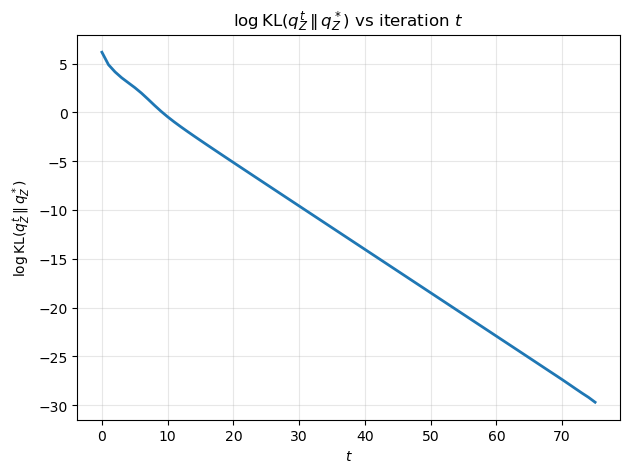

First 10 log-KL values:
[6.16530645 4.88660188 4.14699666 3.55114188 3.04375113 2.5408896
 1.98355744 1.36219394 0.72073866 0.10894703]
Estimated tail slope: -0.445012


In [3]:
# =============================================================================
# exponential convergence
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import scipy.linalg

# -----------------------------
# DATA GENERATION
# -----------------------------
def generate_data_matrix_rng(rng: np.random.Generator, n: int, d: int, rho: float) -> np.ndarray:
    cov = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(cov, 1.0)
    X = rng.multivariate_normal(mean=np.zeros(d), cov=cov, size=n)
    return X.T  # shape (d, n)

# -----------------------------
# KL HELPERS
# -----------------------------
def kl_mvn_stable(to, fr):
    """
    KL( N(m_to, S_to) || N(m_fr, S_fr) )
    """
    m_to, S_to = to
    m_fr, S_fr = fr
    diff = m_fr - m_to

    c, lower = scipy.linalg.cho_factor(S_fr)
    solve = lambda B: scipy.linalg.cho_solve((c, lower), B)

    sign_fr, logdet_fr = np.linalg.slogdet(S_fr)
    sign_to, logdet_to = np.linalg.slogdet(S_to)
    if sign_fr <= 0 or sign_to <= 0:
        raise ValueError("Covariance not positive definite.")

    term1 = np.trace(solve(S_to))
    term2 = logdet_fr - logdet_to
    term3 = diff.T @ solve(diff)
    p = len(m_to)
    return 0.5 * (term1 + term2 + term3 - p)

def matrix_kl_divergence(mu1, Sigma1, mu2, Sigma2):
    """
    KL between matrix-normal laws with row covariance I:
        q1 = MN(mu1, I ⊗ Sigma1), q2 = MN(mu2, I ⊗ Sigma2)
    """
    m, _ = mu1.shape
    total = 0.0
    for i in range(m):
        total += kl_mvn_stable((mu1[i, :], Sigma1), (mu2[i, :], Sigma2))
    return total

# -----------------------------
# PPCA / CAVI HELPERS
# -----------------------------
def estimate_tau_ppca(x, k):
    d, n = x.shape
    S = (1 / n) * (x @ x.T)
    eigenvalues, _ = eigh(S)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if d - k > 0:
        sigma_squared = np.mean(eigenvalues[k:])
    else:
        sigma_squared = 1e-6
    return 1.0 / sigma_squared

def cavi_to_fixed_point(mu_W, sigma_W, mu_z, sigma_z, Lambda, x, tau, d, n, k,
                        tol=1e-13, max_iterations=100000):
    """
    Run CAVI to convergence and return the fixed point.
    """
    increment = 50.0
    ELBOS = []
    iteration = 0

    while increment > tol and iteration < max_iterations:
        iteration += 1

        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        if iteration % 100 == 0:
            term1 = d * sigma_W + (mu_W.T @ mu_W)
            term2 = n * sigma_z + (mu_z.T @ mu_z)
            B = np.trace(term1 @ term2)
            C = d * np.trace(Lambda @ sigma_W) + np.trace((mu_W @ Lambda) @ mu_W.T)
            D = np.trace(n * sigma_z + (mu_z.T @ mu_z))

            _, logdet_W = np.linalg.slogdet(sigma_W)
            _, logdet_z = np.linalg.slogdet(sigma_z)

            ELBO = (
                tau * np.trace((mu_W @ mu_z.T) @ x.T)
                - 0.5 * tau * B
                - 0.5 * C
                - 0.5 * D
                + 0.5 * d * logdet_W
                + 0.5 * n * logdet_z
            )
            ELBOS.append(ELBO)

            if len(ELBOS) >= 2:
                denom = max(abs(ELBOS[-2]), 1e-300)
                increment = abs((ELBOS[-1] - ELBOS[-2]) / denom)

    return mu_W, sigma_W, mu_z, sigma_z

def cavi_track_log_kl(mu_W, sigma_W, mu_z, sigma_z, Lambda, x, tau, d, n, k,
                      mu_z_star, sigma_z_star, max_iterations=300):
    """
    Rerun CAVI from the SAME initialization and record
    log KL(q_Z^t || q_Z^*) at every iteration.
    """
    log_kl_vals = []
    iters = []

    eps = 1e-300

    # t = 0
    kl0 = matrix_kl_divergence(mu_z, sigma_z, mu_z_star, sigma_z_star)
    log_kl_vals.append(np.log(max(kl0, eps)))
    iters.append(0)

    for t in range(1, max_iterations + 1):
        sigma_W_inv = tau * (mu_z.T @ mu_z) + tau * n * sigma_z + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)
        mu_W = tau * (x @ mu_z) @ sigma_W

        sigma_z_inv = tau * (d * sigma_W + (mu_W.T @ mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)
        mu_z = tau * (x.T @ mu_W) @ sigma_z

        kl_t = matrix_kl_divergence(mu_z, sigma_z, mu_z_star, sigma_z_star)
        log_kl_vals.append(np.log(max(kl_t, eps)))
        iters.append(t)

    return np.array(iters), np.array(log_kl_vals)

# -----------------------------
# EXPERIMENT SETTINGS
# -----------------------------
n = 50
d = 3
k = 2
rho = 0.7
alpha = 1.0
dataset_seed = 41
init_seed = 123   

# -----------------------------
# GENERATE ONE DATASET
# -----------------------------
rng_data = np.random.default_rng(dataset_seed)
x = generate_data_matrix_rng(rng_data, n=n, d=d, rho=rho)

tau = estimate_tau_ppca(x, k)
Lambda = alpha * np.eye(k)

# -----------------------------
# FIX ONE INITIALIZATION
# -----------------------------
rng_init = np.random.default_rng(init_seed)
mu_W0 = rng_init.standard_normal((d, k))
sigma_W0 = np.eye(k)
mu_z0 = rng_init.standard_normal((n, k))
sigma_z0 = np.eye(k)

# -----------------------------
# STEP 1: compute q_Z^* from the initialization
# -----------------------------
mu_W_star, sigma_W_star, mu_z_star, sigma_z_star = cavi_to_fixed_point(
    mu_W0.copy(), sigma_W0.copy(), mu_z0.copy(), sigma_z0.copy(),
    Lambda, x, tau, d, n, k
)

# -----------------------------
# STEP 2: track log KL(q_Z^t || q_Z^*)
# -----------------------------
iters, log_kl_vals = cavi_track_log_kl(
    mu_W0.copy(), sigma_W0.copy(), mu_z0.copy(), sigma_z0.copy(),
    Lambda, x, tau, d, n, k,
    mu_z_star, sigma_z_star,
    max_iterations=75
)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7, 5))
plt.plot(iters, log_kl_vals, linewidth=2)
plt.xlabel(r"$t$")
plt.ylabel(r"$\log \mathrm{KL}(q_Z^{t}\,\|\,q_Z^*)$")
plt.title(r"$\log \mathrm{KL}(q_Z^{t}\,\|\,q_Z^*)$ vs iteration $t$")
plt.grid(True, alpha=0.3)
plt.savefig("plot_exp_convergence.pdf", bbox_inches="tight")
plt.show()
print("First 10 log-KL values:")
print(log_kl_vals[:10])
start_fit = 20
coef = np.polyfit(iters[start_fit:], log_kl_vals[start_fit:], 1)
print(f"Estimated tail slope: {coef[0]:.6f}")

In [5]:
n,d,k,tau = 100,10,1,100
diagonal_elements = [1]
matrix = np.diag(diagonal_elements)
W,Lambda = np.ones((d, k)), np.eye(k)
W[0][0] =1
W,Lambda

(array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]]),
 array([[1.]]))

In [7]:
np.random.seed(101) #seed = 41,51,...

# Latent variable: Generate a 100x1 vector with independent N(0, 1) random numbers
z = np.random.normal(0, 1, size=(n, k))
#compute the data
x0= np.dot(W,np.transpose(z))
norm_of_raw_data = np.linalg.norm(x0,ord=2)
x0.shape,norm_of_raw_data

((10, 100), 33.112845607078576)

In [9]:
# Seed
np.random.seed(450)

# Generate the random matrix
mean = np.zeros(d)  # Mean vector of size 10
cov = (1/tau) * np.eye(d)  # Covariance matrix of size 10x10
E = np.random.multivariate_normal(mean, cov, size= n).T
# contaminate the data
x = x0+E
mu_z = np.full((n, k),0.1)

x.shape, mu_z.shape

((10, 100), (100, 1))

In [11]:
import numpy as np
# Compute the eigenvalues and eigenvectors of xx^T
xxT = np.dot(x, x.T)
left_eigenvalues, left_eigenvectors = np.linalg.eigh(xxT)

# Compute the eigenvalues and eigenvectors of x^T x
xTx = np.dot(x.T, x)
right_eigenvalues, right_eigenvectors = np.linalg.eigh(xTx)

# Sort the eigenvalues and eigenvectors in descending order
left_indices = np.argsort(left_eigenvalues)[::-1]
left_eigenvalues = left_eigenvalues[left_indices]
left_eigenvectors = left_eigenvectors[:, left_indices]

right_indices = np.argsort(right_eigenvalues)[::-1]
right_eigenvalues = right_eigenvalues[right_indices]
right_eigenvectors = right_eigenvectors[:, right_indices]

v =right_eigenvectors[:,0].reshape(n, 1)
v11=right_eigenvectors[:,1].reshape(n, 1) 
v12 = right_eigenvectors[:,2].reshape(n, 1)
u =left_eigenvectors[:,0].reshape(d, 1)
max(right_eigenvalues)


1098.453032991065

In [13]:
import numpy as np

def recurrence_iteration(a, b, Lambda):
    tau = 100
    # Create lists to store the iteration values
    a_vals = [a]
    b_vals = [b]
    
    for i in range(150000):
        try:
            # Compute L and the denominator
            L = (tau * (n * b + a * a)) + Lambda
            denominator = d * tau * L + (tau ** 3) * a * a * max(right_eigenvalues) + L * L
            
            # Avoid division by zero or unstable values
            if denominator == 0 or np.isinf(denominator) or np.isnan(denominator):
                print("Denominator became zero or unstable!")
                break
            
            # Update b
            b = (L * L) / denominator
            # Update a
            a = (tau * tau * a * L * max(right_eigenvalues)) / denominator

            # Store the new values in the lists
            a_vals.append(a)
            b_vals.append(b)
            
            # Print first few iterations for inspection
            if i in range(0, 3):
                print((a, b))
            
            # Check if new values are unstable
            if np.isnan(a) or np.isnan(b) or np.isinf(a) or np.isinf(b):
                print("Values became unstable!")
                break
            
        except OverflowError as e:
            print("Overflow encountered:", e)
            break

    return a_vals, b_vals

# --- Initialization of parameters ---
a = 1
b = 12
Lambda = 1


# Run the recurrence iteration and get all iteration values for a and b
a_vals, b_vals = recurrence_iteration(a, b, Lambda)
final_a = a_vals[-1]
final_b = b_vals[-1]
# Print final values from the recurrence (last elements in the lists)
print("Final a:", a_vals[-1])
print("Final b:", b_vals[-1])


(84.33609840145702, 0.9221013051903313)
(80.1002667831906, 0.06229608453435514)
(75.73876072598429, 0.05528315381489312)
Final a: 10.039223865837567
Final b: 0.0009184540276287452


In [15]:
import numpy as np
# Compute the eigenvalues and eigenvectors of xx^T
xxT = np.dot(x, x.T)
left_eigenvalues, left_eigenvectors = np.linalg.eigh(xxT)

# Compute the eigenvalues and eigenvectors of x^T x
xTx = np.dot(x.T, x)
right_eigenvalues, right_eigenvectors = np.linalg.eigh(xTx)

# Sort the eigenvalues and eigenvectors in descending order
left_indices = np.argsort(left_eigenvalues)[::-1]
left_eigenvalues = left_eigenvalues[left_indices]
left_eigenvectors = left_eigenvectors[:, left_indices]

right_indices = np.argsort(right_eigenvalues)[::-1]
right_eigenvalues = right_eigenvalues[right_indices]
right_eigenvectors = right_eigenvectors[:, right_indices]

v =right_eigenvectors[:,0].reshape(n, 1)
v11=right_eigenvectors[:,1].reshape(n, 1) 
v12 = right_eigenvectors[:,2].reshape(n, 1)
u =left_eigenvectors[:,0].reshape(d, 1)
max(right_eigenvalues)


1098.453032991065

In [17]:
# Cell: LaTeX Display of Mathematical Formulation
from IPython.display import display, Markdown, Latex

latex_formulation = r"""
## Mathematical Formulation

**Main Polynomial:**
$$P(x) = x^4 + ax^3 + bx^2 + cx + f = 0$$

Where $x_0$ is the **second largest real root** of this quartic polynomial.

**Given:**
$$\gamma = \sqrt{\lambda}$$

**Coefficient Definitions:**

$$a = \frac{(n-d)^2}{nd} \cdot \gamma$$

$$\eta^2 = \left(1 - \frac{d}{\tau \gamma^2}\right)\left(1 - \frac{n}{\tau \gamma^2}\right)\gamma^2$$

$$f = \left(\eta^2 - \frac{1}{\tau^2}\right)^2$$

$$c = a\sqrt{f}$$

$$b = -\left(a\gamma + \frac{(n^2 + d^2)\eta^2}{nd} + \frac{2}{\tau^2}\right)$$

**Objective:** Find $x_0$ (second largest real root of $P(x) = 0$)
"""

display(Latex(latex_formulation))

# Cell: Function to compute coefficients and solve quartic
def solve_quartic_second_largest(n, d, tau, lam):
    """
    Solve the quartic polynomial and return the second largest real root.
    
    Parameters:
    n, d, tau: problem parameters
    lam: lambda parameter (γ = √λ)
    
    Returns:
    x0: second largest real root
    coefficients: [a, b, c, f]
    all_roots: all roots of the polynomial
    """
    
    # Step 1: Calculate γ
    gamma = np.sqrt(lam)
    print(f"γ = √λ = √{lam} = {gamma:.6f}")
    
    # Step 2: Calculate η²
    eta_squared = (1 - d/(tau * gamma**2)) * (1 - n/(tau * gamma**2)) * gamma**2
    print(f"η² = {eta_squared:.6f}")
    
    # Step 3: Calculate f
    f = (eta_squared - (1/tau)**2)**2
    print(f"f = (η² - 1/τ²)² = {f:.6f}")
    
    # Step 4: Calculate a
    a = ((n - d)**2 / (n * d)) * gamma
    print(f"a = ((n-d)²/nd)γ = {a:.6f}")
    
    # Step 5: Calculate c
    c = a * np.sqrt(f)
    print(f"c = a√f = {c:.6f}")
    
    # Step 6: Calculate b
    b = -(a * gamma + (n**2 + d**2) * eta_squared / (n * d) + 2/tau**2)
    print(f"b = -{a * gamma:.6f} - {(n**2 + d**2) * eta_squared / (n * d):.6f} - {2/tau**2:.6f} = {b:.6f}")
    
    # Step 7: Solve quartic equation P(x) = x⁴ + ax³ + bx² + cx + f = 0
    coefficients = [1, a, b, c, f]  # coefficients for numpy.roots (highest degree first)
    print(f"\nPolynomial coefficients [1, a, b, c, f]: {coefficients}")
    
    # Find all roots
    all_roots = np.roots(coefficients)
    print(f"All roots: {all_roots}")
    
    # Filter real roots (with small tolerance for numerical errors)
    real_roots = []
    for root in all_roots:
        if abs(root.imag) < 1e-10:  # essentially real
            real_roots.append(root.real)
    
    real_roots = np.array(real_roots)
    print(f"Real roots: {real_roots}")
    
    if len(real_roots) < 2:
        raise ValueError(f"Need at least 2 real roots, but found only {len(real_roots)}")
    
    # Sort in descending order and get second largest
    real_roots_sorted = np.sort(real_roots)[::-1]  # descending order
    x0 = real_roots_sorted[1]  # second largest
    
    print(f"Real roots (sorted descending): {real_roots_sorted}")
    print(f"Second largest real root x₀ = {x0:.6f}")
    
    return x0, [a, b, c, f], all_roots


lam = max(right_eigenvalues)   

print("Parameters:")
print(f"n = {n}")
print(f"d = {d}")
print(f"τ = {tau}")
print(f"λ = {lam}")
print("="*50)

# Solve the quartic
try:
    x0, coeffs, roots = solve_quartic_second_largest(n, d, tau, lam)
    
    print("\n" + "="*50)
    print("RESULTS:")
    print(f"Second largest real root: x₀ = {x0:.6f}")
    print(f"Polynomial coefficients [a, b, c, f]: {coeffs}")
    
    # Verify the solution
    a, b, c, f = coeffs
    verification = x0**4 + a*x0**3 + b*x0**2 + c*x0 + f
    print(f"Verification P(x₀) = {verification:.2e} (should be ≈ 0)")
    
except Exception as e:
    print(f"Error: {e}")

# Cell: Plotting function (optional)
def plot_polynomial(coeffs, roots, x0):
    """Plot the polynomial and highlight the roots"""
    import matplotlib.pyplot as plt
    
    a, b, c, f = coeffs
    
    # Create x values for plotting
    real_roots = [r.real for r in roots if abs(r.imag) < 1e-10]
    x_min, x_max = min(real_roots) - 2, max(real_roots) + 2
    x = np.linspace(x_min, x_max, 1000)
    
    # Calculate polynomial values
    y = x**4 + a*x**3 + b*x**2 + c*x + f
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', linewidth=2, label=f'P(x) = x⁴ + {a:.3f}x³ + {b:.3f}x² + {c:.3f}x + {f:.3f}')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Mark all real roots
    for root in roots:
        if abs(root.imag) < 1e-10:
            plt.plot(root.real, 0, 'ro', markersize=8)
    
    # Highlight the second largest root
    plt.plot(x0, 0, 'go', markersize=12, label=f'x₀ = {x0:.3f} (2nd largest)')
    
    plt.xlabel('x')
    plt.ylabel('P(x)')
    plt.title('Quartic Polynomial and its Roots')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Uncomment the next line to plot
# plot_polynomial(coeffs, roots, x0)

<IPython.core.display.Latex object>

Parameters:
n = 100
d = 10
τ = 100
λ = 1098.453032991065
γ = √λ = √1098.453032991065 = 33.142918
η² = 1097.353124
f = (η² - 1/τ²)² = 1204183.659344
a = ((n-d)²/nd)γ = 268.457638
c = a√f = 294592.801075
b = -8897.469567 - 11083.266553 - 0.000200 = -19980.736320

Polynomial coefficients [1, a, b, c, f]: [1, 268.45763817508293, -19980.736319912285, 294592.8010748914, 1204183.659343801]
All roots: [-331.39901088   33.14318618   33.10946081   -3.31127429]
Real roots: [-331.39901088   33.14318618   33.10946081   -3.31127429]
Real roots (sorted descending): [  33.14318618   33.10946081   -3.31127429 -331.39901088]
Second largest real root x₀ = 33.109461

RESULTS:
Second largest real root: x₀ = 33.109461
Polynomial coefficients [a, b, c, f]: [268.45763817508293, -19980.736319912285, 294592.8010748914, 1204183.659343801]
Verification P(x₀) = 1.07e-08 (should be ≈ 0)


In [23]:
# Cell: LaTeX Display of Mathematical Formulation
from IPython.display import display, Markdown, Latex

latex_formulation = r"""
## Mathematical Formulation

**Main Polynomial:**
$$P(x) = x^4 + ax^3 + bx^2 + cx + f = 0$$

Where $x_0$ is the **second largest real root** of this quartic polynomial.

**Given:**
$$\gamma = \sqrt{\lambda}$$

**Coefficient Definitions:**

$$a = \frac{(n-d)^2}{nd} \cdot \gamma$$

$$\eta^2 = \left(1 - \frac{d}{\tau \gamma^2}\right)\left(1 - \frac{n}{\tau \gamma^2}\right)\gamma^2$$

$$f = \left(\eta^2 - \frac{1}{\tau^2}\right)^2$$

$$c = a\sqrt{f}$$

$$b = -\left(a\gamma + \frac{(n^2 + d^2)\eta^2}{nd} + \frac{2}{\tau^2}\right)$$

**Objective:** Find $x_0$ (second largest real root of $P(x) = 0$)
"""

display(Latex(latex_formulation))

# Cell: Function to compute coefficients and solve quartic
def solve_quartic_second_largest(n, d, tau, lam):
    """
    Solve the quartic polynomial and return the second largest real root.
    
    Parameters:
    n, d, tau: problem parameters
    lam: lambda parameter (γ = √λ)
    
    Returns:
    x0: second largest real root
    coefficients: [a, b, c, f]
    all_roots: all roots of the polynomial
    """
    
    # Step 1: Calculate γ
    gamma = np.sqrt(lam)
    print(f"γ = √λ = √{lam} = {gamma:.6f}")
    
    # Step 2: Calculate η²
    eta_squared = (1 - d/(tau * gamma**2)) * (1 - n/(tau * gamma**2)) * gamma**2
    print(f"η² = {eta_squared:.6f}")
    
    # Step 3: Calculate f
    f = (eta_squared - (1/tau)**2)**2
    print(f"f = (η² - 1/τ²)² = {f:.6f}")
    
    # Step 4: Calculate a
    a = ((n - d)**2 / (n * d)) * gamma
    print(f"a = ((n-d)²/nd)γ = {a:.6f}")
    
    # Step 5: Calculate c
    c = a * np.sqrt(f)
    print(f"c = a√f = {c:.6f}")
    
    # Step 6: Calculate b
    b = -(a * gamma + (n**2 + d**2) * eta_squared / (n * d) + 2/tau**2)
    print(f"b = -{a * gamma:.6f} - {(n**2 + d**2) * eta_squared / (n * d):.6f} - {2/tau**2:.6f} = {b:.6f}")
    
    # Step 7: Solve quartic equation P(x) = x⁴ + ax³ + bx² + cx + f = 0
    coefficients = [1, a, b, c, f]  # coefficients for numpy.roots (highest degree first)
    print(f"\nPolynomial coefficients [1, a, b, c, f]: {coefficients}")
    
    # Find all roots
    all_roots = np.roots(coefficients)
    print(f"All roots: {all_roots}")
    
    # Filter real roots (with small tolerance for numerical errors)
    real_roots = []
    for root in all_roots:
        if abs(root.imag) < 1e-10:  # essentially real
            real_roots.append(root.real)
    
    real_roots = np.array(real_roots)
    print(f"Real roots: {real_roots}")
    
    if len(real_roots) < 2:
        raise ValueError(f"Need at least 2 real roots, but found only {len(real_roots)}")
    
    # Sort in descending order and get second largest
    real_roots_sorted = np.sort(real_roots)[::-1]  # descending order
    x0 = real_roots_sorted[1]  # second largest
    
    print(f"Real roots (sorted descending): {real_roots_sorted}")
    print(f"Second largest real root x₀ = {x0:.6f}")
    
    return x0, [a, b, c, f], all_roots


lam =  max(right_eigenvalues)     
print("Parameters:")
print(f"n = {n}")
print(f"d = {d}")
print(f"τ = {tau}")
print(f"λ = {lam}")
print("="*50)

# Solve the quartic
try:
    x0, coeffs, roots = solve_quartic_second_largest(n, d, tau, lam)
    
    print("\n" + "="*50)
    print("RESULTS:")
    print(f"Second largest real root: x₀ = {x0:.6f}")
    print(f"Polynomial coefficients [a, b, c, f]: {coeffs}")
    
    # Verify the solution
    a, b, c, f = coeffs
    verification = x0**4 + a*x0**3 + b*x0**2 + c*x0 + f
    print(f"Verification P(x₀) = {verification:.2e} (should be ≈ 0)")
    
except Exception as e:
    print(f"Error: {e}")

# Cell: Plotting function (optional)
def plot_polynomial(coeffs, roots, x0):
    """Plot the polynomial and highlight the roots"""
    import matplotlib.pyplot as plt
    
    a, b, c, f = coeffs
    
    # Create x values for plotting
    real_roots = [r.real for r in roots if abs(r.imag) < 1e-10]
    x_min, x_max = min(real_roots) - 2, max(real_roots) + 2
    x = np.linspace(x_min, x_max, 1000)
    
    # Calculate polynomial values
    y = x**4 + a*x**3 + b*x**2 + c*x + f
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', linewidth=2, label=f'P(x) = x⁴ + {a:.3f}x³ + {b:.3f}x² + {c:.3f}x + {f:.3f}')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Mark all real roots
    for root in roots:
        if abs(root.imag) < 1e-10:
            plt.plot(root.real, 0, 'ro', markersize=8)
    
    # Highlight the second largest root
    plt.plot(x0, 0, 'go', markersize=12, label=f'x₀ = {x0:.3f} (2nd largest)')
    
    plt.xlabel('x')
    plt.ylabel('P(x)')
    plt.title('Quartic Polynomial and its Roots')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Uncomment the next line to plot
# plot_polynomial(coeffs, roots, x0)

# Cell: Calculate y₀ and δ using the second largest root x₀
from IPython.display import display, Latex

# Display the mathematical formulation for this step
latex_additional = r"""
## Additional Calculations

**Given the second largest root $x_0$, calculate:**

$y_0 = (n - d)(\gamma - x_0)$

$\delta = \frac{\tau}{2n} \left[ y_0 + \sqrt{y_0^2 + \frac{4nd}{\tau^2}} \right]$
"""

display(Latex(latex_additional))

def calculate_y0_and_delta(x0, gamma, n, d, tau):
    """
    Calculate y₀ and δ using the second largest root x₀
    
    Parameters:
    x0: second largest real root
    gamma: γ = √λ
    n, d, tau: problem parameters
    
    Returns:
    y0, delta: calculated values
    """
    
    print("="*50)
    print("ADDITIONAL CALCULATIONS:")
    print("="*50)
    
    # Calculate y₀
    y0 = (n - d) * (gamma - x0)
    print(f"y₀ = (n - d)(γ - x₀)")
    print(f"y₀ = ({n} - {d})({gamma:.6f} - {x0:.6f})")
    print(f"y₀ = {n - d:.6f} × {gamma - x0:.6f}")
    print(f"y₀ = {y0:.6f}")
    
    # Calculate the discriminant-like term
    discriminant = y0**2 + (4*n*d)/(tau**2)
    print(f"\nDiscriminant term: y₀² + 4nd/τ²")
    print(f"= {y0:.6f}² + (4×{n}×{d})/{tau}²")
    print(f"= {y0**2:.6f} + {4*n*d:.6f}/{tau**2:.6f}")
    print(f"= {y0**2:.6f} + {(4*n*d)/(tau**2):.6f}")
    print(f"= {discriminant:.6f}")
    
    # Calculate δ
    sqrt_term = np.sqrt(discriminant)
    delta = (tau / (2*n)) * (y0 + sqrt_term)
    
    print(f"\n√(discriminant) = √{discriminant:.6f} = {sqrt_term:.6f}")
    print(f"\nδ = (τ/2n)[y₀ + √(y₀² + 4nd/τ²)]")
    print(f"δ = ({tau}/(2×{n}))[{y0:.6f} + {sqrt_term:.6f}]")
    print(f"δ = {tau/(2*n):.6f} × {y0 + sqrt_term:.6f}")
    print(f"δ = {delta:.6f}")
    
    return y0, delta

# Calculate y₀ and δ using the previously found x₀
if 'x0' in locals() and 'coeffs' in locals():
    gamma = np.sqrt(lam)  # Recalculate gamma for clarity
    y0, delta = calculate_y0_and_delta(x0, gamma, n, d, tau)
    
    print("\n" + "="*50)
    print("FINAL RESULTS:")
    print("="*50)
    print(f"x₀ (second largest root) = {x0:.6f}")
    print(f"y₀ = {y0:.6f}")
    print(f"δ = {delta:.6f}")
else:
    print("Run the previous cells first to calculate x₀")

<IPython.core.display.Latex object>

Parameters:
n = 100
d = 10
τ = 100
λ = 1098.453032991065
γ = √λ = √1098.453032991065 = 33.142918
η² = 1097.353124
f = (η² - 1/τ²)² = 1204183.659344
a = ((n-d)²/nd)γ = 268.457638
c = a√f = 294592.801075
b = -8897.469567 - 11083.266553 - 0.000200 = -19980.736320

Polynomial coefficients [1, a, b, c, f]: [1, 268.45763817508293, -19980.736319912285, 294592.8010748914, 1204183.659343801]
All roots: [-331.39901088   33.14318618   33.10946081   -3.31127429]
Real roots: [-331.39901088   33.14318618   33.10946081   -3.31127429]
Real roots (sorted descending): [  33.14318618   33.10946081   -3.31127429 -331.39901088]
Second largest real root x₀ = 33.109461

RESULTS:
Second largest real root: x₀ = 33.109461
Polynomial coefficients [a, b, c, f]: [268.45763817508293, -19980.736319912285, 294592.8010748914, 1204183.659343801]
Verification P(x₀) = 1.07e-08 (should be ≈ 0)


<IPython.core.display.Latex object>

ADDITIONAL CALCULATIONS:
y₀ = (n - d)(γ - x₀)
y₀ = (100 - 10)(33.142918 - 33.109461)
y₀ = 90.000000 × 0.033457
y₀ = 3.011173

Discriminant term: y₀² + 4nd/τ²
= 3.011173² + (4×100×10)/100²
= 9.067165 + 4000.000000/10000.000000
= 9.067165 + 0.400000
= 9.467165

√(discriminant) = √9.467165 = 3.076876

δ = (τ/2n)[y₀ + √(y₀² + 4nd/τ²)]
δ = (100/(2×100))[3.011173 + 3.076876]
δ = 0.500000 × 6.088049
δ = 3.044025

FINAL RESULTS:
x₀ (second largest root) = 33.109461
y₀ = 3.011173
δ = 3.044025


In [21]:
(100.786027)**0.5

10.039224422235018